In [1]:
pip install pandas numpy matplotlib scikit-learn torch transformers hf_xet peft

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch import cuda
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.metrics import classification_report, roc_auc_score
import torch
import os
from tqdm.auto import tqdm

RESULTS_DIR      = "results"
CHECKPOINTS_DIR  = "checkpoints"

os.makedirs(RESULTS_DIR, exist_ok=True)
if not os.path.exists(CHECKPOINTS_DIR):
    os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

In [3]:
# Load data
df = pd.read_csv('./dataset/heart_diagnoses.csv')
procedures = pd.read_csv('./dataset/heart_procedures.csv')
diagnosis = pd.read_csv('./dataset/heart_diagnoses_all_true.csv')
labs = pd.read_csv('./dataset/heart_labevents_first_lab.csv')


## EDA + Preprocessing

### EDA for MI patients

How many MI patients who have complete data from HPI (or can be replaced by chief complaints and physical examination), ECG clinician-generated report, Troponin-T lab result, and CATH report?

In [4]:
# 1. Filter to MI patients (I21, I22)
mi_codes = diagnosis[diagnosis['icd_code'].str.startswith(('I21', 'I22'))]
mi_patients = df[df['hadm_id'].isin(mi_codes['hadm_id'])]
print(f"MI patients: {len(mi_patients)}")

MI patients: 1560


In [5]:
# 2. Check who got CATH
# Use keyword "cath" in ICD_code long_title in heart_procedures.csv
icd_code_cath = ['3722', '8856', '3723', '3721', '3897', '3893', '3891', '3726', '3895', '8855', '3404', '5794', '598']
cath_procedures = procedures[procedures['icd_code'].astype(str).isin(icd_code_cath)]

mi_patients['got_cath'] = mi_patients['hadm_id'].isin(cath_procedures['hadm_id'])
print(f"MI patients who got CATH: {mi_patients['got_cath'].sum()} ({mi_patients['got_cath'].mean()*100:.1f}%)")


MI patients who got CATH: 968 (62.1%)


/tmp/ipython-input-1609565979.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['got_cath'] = mi_patients['hadm_id'].isin(cath_procedures['hadm_id'])


In [6]:
## Double check!
# Check how many patients who have a valid CATH report from heart_diagnoses.csv
cath_report = df[~(df['CATH'].str.contains(r'(not available|pending|\[\])', case=False, na=False) & (df['CATH'].str.len() < 200))]

mi_patients['cath_report'] = mi_patients['hadm_id'].isin(cath_report['hadm_id'])
print(f"MI patients who have CATH report: {mi_patients['got_cath'].sum()} ({mi_patients['got_cath'].mean()*100:.1f}%)")

MI patients who have CATH report: 968 (62.1%)


/tmp/ipython-input-1308324954.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cath_report = df[~(df['CATH'].str.contains(r'(not available|pending|\[\])', case=False, na=False) & (df['CATH'].str.len() < 200))]
/tmp/ipython-input-1308324954.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['cath_report'] = mi_patients['hadm_id'].isin(cath_report['hadm_id'])


Both methods are reliable to produce the same amount of result.

In [7]:
# 3. Check ECG availability
mi_patients['has_ecg'] = mi_patients['ECG'].str.contains(r'\[\]', case=False, na=False)  # clinician report
mi_patients['has_ecg_machine'] = mi_patients['reports'].notna()  # machine report
print(f"Has clinician ECG: {mi_patients['has_ecg'].sum()}")
print(f"Has machine ECG: {mi_patients['has_ecg_machine'].sum()}")


Has clinician ECG: 564
Has machine ECG: 1560


/tmp/ipython-input-473121965.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['has_ecg'] = mi_patients['ECG'].str.contains(r'\[\]', case=False, na=False)  # clinician report
/tmp/ipython-input-473121965.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['has_ecg_machine'] = mi_patients['reports'].notna()  # machine report


In [8]:
# 4. Check chief complaints availability
mi_patients.loc[:, 'has_complaints'] = mi_patients['chief_complaint'].notna()
print(f"Has complaints: {mi_patients['has_complaints'].sum()}")

Has complaints: 1558


/tmp/ipython-input-2285016077.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients.loc[:, 'has_complaints'] = mi_patients['chief_complaint'].notna()


In [9]:
# 5. Check physical exam availability
mi_patients.loc[:, 'has_phys'] = mi_patients['physical_exam'].notna()
print(f"Has physical exams: {mi_patients['has_phys'].sum()}")

Has physical exams: 1560


/tmp/ipython-input-2382092274.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients.loc[:, 'has_phys'] = mi_patients['physical_exam'].notna()


In [10]:
# 6. Check troponin availability
troponin_labs = labs[labs['label'].str.contains('troponin', case=False, na=False)]
mi_patients['has_troponin'] = mi_patients['hadm_id'].isin(troponin_labs['hadm_id'])
print(f"Has troponin: {mi_patients['has_troponin'].sum()}")

Has troponin: 1477


/tmp/ipython-input-2164853698.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['has_troponin'] = mi_patients['hadm_id'].isin(troponin_labs['hadm_id'])


### Preprocessing

In [11]:
all_patients = df.copy()
print(f"Total cardiac patients: {len(all_patients)}")

Total cardiac patients: 4761


In [12]:
# Create binary CATH label (0 or 1)

def has_valid_cath(cath_text):
    if pd.isna(cath_text):
        return 0
    cath_str = str(cath_text).lower()
    # Exclude invalid reports
    if any(x in cath_str for x in ['not available', 'pending', '[]']):
        return 0
    if len(cath_str) < 200:  # Too short to be real report
        return 0
    return 1

all_patients['cath_label'] = all_patients['CATH'].apply(has_valid_cath)
print(f"CATH=1: {all_patients['cath_label'].sum()} ({all_patients['cath_label'].mean()*100:.1f}%)")
print(f"CATH=0: {(all_patients['cath_label']==0).sum()} ({(all_patients['cath_label']==0).mean()*100:.1f}%)")


CATH=1: 2090 (43.9%)
CATH=0: 2671 (56.1%)


In [13]:
# Add Troponin processing with 4 classes

troponin_labs = labs[labs['label'].str.contains('troponin', case=False, na=False)]
troponin_first = troponin_labs.sort_values('charttime').groupby('hadm_id').first().reset_index()

def categorize_troponin(row):
    """
    4 categories:
    - 'abnormal': elevated troponin (beyond upper bound)
    - 'normal': detected within normal range
    - 'not_detected': very low or almost zero (below lower bound)
    - 'not_tested': no data
    """
    flag = str(row.get('flag', '')).lower()
    valuenum = row.get('valuenum', None)
    ref_upper = row.get('ref_range_upper', None)

    # Check flag
    if 'abnormal' in flag or 'high' in flag:
        return 'abnormal'

    # Check numeric value
    if pd.notna(valuenum):
        if valuenum <= 0.01:
            return 'not_detected'
        if pd.notna(ref_upper) and valuenum > ref_upper:
            return 'abnormal'
        return 'normal'

    return 'not_tested'

# Apply troponin categorization
troponin_dict = {}
for _, row in troponin_first.iterrows():
    troponin_dict[row['hadm_id']] = categorize_troponin(row)

all_patients['troponin_status'] = all_patients['hadm_id'].map(troponin_dict).fillna('not_tested')

print(all_patients['troponin_status'].value_counts())


troponin_status
abnormal        2405
not_tested      2253
not_detected     103
Name: count, dtype: int64


In [14]:
# Create MI or non MI diagnosis for multi agent
mi_codes = diagnosis[diagnosis['icd_code'].str.startswith(('I21', 'I22'))]
all_patients['mi_label'] = all_patients['hadm_id'].isin(mi_codes['hadm_id']).astype(int)

print(f"MI=1: {all_patients['mi_label'].sum()} ({all_patients['mi_label'].mean()*100:.1f}%)")
print(f"MI=0: {(all_patients['mi_label']==0).sum()} ({(all_patients['mi_label']==0).mean()*100:.1f}%)")

MI=1: 1560 (32.8%)
MI=0: 3201 (67.2%)


In [15]:
# Create combined ECG field (prefer clinician, fallback to machine)
def get_ecg_text(row):
    if pd.notna(row['ECG']):
        ecg_clean = str(row['ECG']).strip()
        if ecg_clean and ecg_clean != '[]' and len(ecg_clean) > 10:
            return ecg_clean

    if pd.notna(row['reports']):
        return str(row['reports'])
    return None

all_patients['ecg_text'] = all_patients.apply(get_ecg_text, axis=1)
all_patients['has_ecg'] = all_patients['ecg_text'].notna()
print(f"Has ECG: {all_patients['has_ecg'].sum()}")

Has ECG: 4761


In [16]:
# For checking emptyrow/whitespace
def is_valid_text(text):
    if pd.isna(text):
        return False
    text_clean = str(text).strip()
    return len(text_clean) > 0 and text_clean not in ['[]', 'nan', 'None']

In [17]:
# Check chief complaints availability
all_patients['has_complaints'] = all_patients['chief_complaint'].apply(is_valid_text)
print(f"Has valid complaints: {all_patients['has_complaints'].sum()}")

Has valid complaints: 4749


In [18]:
# Check physical exam
all_patients['has_phys'] = all_patients['physical_exam'].apply(is_valid_text)
print(f"Has valid physical exams: {all_patients['has_phys'].sum()}")

Has valid physical exams: 4761


In [19]:
# Check history
all_patients['has_hist'] = all_patients['HPI'].apply(is_valid_text)
print(f"Has valid HPI: {all_patients['has_hist'].sum()}")

Has valid HPI: 4761


Clean HPI data leak

In [20]:
# Data leak detection (Rule-Based)

import re

def detect_cath_leakage(text):
    """
    Detect mentions of CATH procedure in clinical text
    Returns: (has_leakage: bool, matched_terms: list, leakage_score: float)
    """
    if pd.isna(text):
        return False, [], 0.0

    text_lower = str(text).lower()

    # Define leakage patterns
    leakage_patterns = {
        # DIRECT PROCEDURE MENTIONS (most obvious)
        'direct_procedure': [
            r'\bcath\b(?!eter\b)',  # "cath" but not "catheter"
            r'catheterization',
            r'cardiac cath',
            r'cath lab',
            r'cath\s+showed',
            r'cath\s+revealed',
            r'underwent\s+cath',
            r'taken\s+to\s+cath',
            r'sent\s+to\s+cath',
            r'post[\s-]cath',
            r'pre[\s-]cath',
            r'during\s+cath',
            r'angiography',
            r'angiogram',
            r'coronary\s+angio',
        ],

        # PROCEDURAL DETAILS
        'procedural_details': [
            r'femoral\s+access',
            r'radial\s+access',
            r'arterial\s+sheath',
            r'guide\s+wire',
            r'stent\s+placed',
            r'stent\s+deployment',
            r'balloon\s+angioplasty',
            r'ptca',
            r'pci',
        ],

        # # POST-PROCEDURE MEDICATIONS
        # 'post_cath_meds': [
        #     r'\bheparin\b',
        #     r'\bplavix\b',
        #     r'clopidogrel',
        #     r'prasugrel',
        #     r'ticagrelor',
        # ],

        # # TRANSFER FOR PROCEDURE
        # 'transfer_for_cath': [
        #     r'transferred\s+for\s+cath',
        #     r'transferred\s+to.*cath',
        #     r'sent\s+for\s+cath',
        # ],

        # # PROCEDURAL RESULTS
        # 'cath_results': [
        #     r'cath\s+demonstrated',
        #     r'cath\s+findings',
        #     r'\w*cath\w*\s+(?:showed|revealed|demonstrated|findings?)',
        #     r'angiography\s+revealed',
        #     r'angiogram\s+showed',
        #     r'demonstrated\s+\w+%',
        #     r'demonstrated\s+(?:stenosis|occlusion|disease)',
        #     r'stenosis\s+of.*%',
        #     r'lad\s+\d+%',
        #     r'lcx\s+\d+%',
        #     r'rca\s+\d+%',
        # ]
      }

    matched_terms = []
    category_scores = {}

    for category, patterns in leakage_patterns.items():
        matches = []
        for pattern in patterns:
            found = re.findall(pattern, text_lower)
            if found:
                matches.extend(found)

        if matches:
            matched_terms.append((category, matches))
            # Weight by severity
            weights = {
                'direct_procedure': 10,
                'procedural_details': 8,
                'transfer_for_cath': 7,
                'cath_results': 6,
                'post_cath_meds': 5
            }
            category_scores[category] = len(matches) * weights.get(category, 5)

    has_leakage = len(matched_terms) > 0
    leakage_score = sum(category_scores.values())

    return has_leakage, matched_terms, leakage_score


def clean_leakage_from_text(text):
    """
    Aggressively remove ALL leakage terms from text
    """
    if pd.isna(text):
        return text

    text_str = str(text)

    # AGGRESSIVE removal - match EXACTLY what detection finds
    removal_patterns = [
        # Direct procedure mentions (MOST IMPORTANT)
        r'\bcath\b(?!eter)',  # Remove "cath" but keep "catheter"
        r'catheterization',
        r'cardiac\s+cath\w*',
        r'cath\s+lab\w*',
        r'angiography',
        r'angiogram\w*',
        r'coronary\s+angio\w*',

        # Procedural phrases
        r'underwent\s+\w*cath\w*',
        r'taken\s+to\s+\w*cath\w*',
        r'sent\s+to\s+\w*cath\w*',
        r'post[\s-]cath\w*',
        r'pre[\s-]cath\w*',
        r'during\s+\w*cath\w*',
        r'after\s+\w*cath\w*',
        r's/p\s+\w*cath\w*',  # "s/p cath" = status post cath

        # # Procedural details
        # r'femoral\s+access',
        # r'radial\s+access',
        # r'arterial\s+sheath',
        # r'guide\s+wire',
        # r'contrast\s+injection',
        # r'stent\w*\s+(?:placed|deployment)',
        # r'balloon\s+angioplasty',
        # r'\bptca\b',
        # r'\bpci\b',

        # # Post-procedure medications (with context)
        # r'heparin\s+(?:drip|infusion|started|gtt)',
        # r'plavix\s+(?:load|started|given)',
        # r'clopidogrel\s+(?:load|started)',
        # r'prasugrel',
        # r'ticagrelor',
        # r'dual\s+antiplatelet',
        # r'\bdapt\b',

        # # Transfer for procedure
        # r'transferred\s+for\s+\w*cath\w*',
        # r'transferred\s+to\s+\w+\s+for\s+\w*cath\w*',
        # r'sent\s+for\s+\w*cath\w*',
        # r'accepted?\s+for\s+\w*cath\w*',

        # # Procedural results
        # r'\w*cath\w*\s+(?:showed|revealed|demonstrated|findings?)',
        # r'angiography\s+revealed',
        # r'angiogram\s+showed',
        # r'coronary\s+anatomy',
        # r'vessel\s+occlusion',

        # # Specific vessel findings (from cath reports)
        # r'stenosis\s+of\s+\d+%',
        # r'\blad\s+\d+%',
        # r'\blcx\s+\d+%',
        # r'\brca\s+\d+%',
        # r'\d+%\s+stenosis',
    ]

    # Apply each pattern
    for pattern in removal_patterns:
        text_str = re.sub(pattern, ' [REDACTED] ', text_str, flags=re.IGNORECASE)

    # Clean up multiple spaces and redaction markers
    text_str = re.sub(r'\[REDACTED\]\s+\[REDACTED\]', '[REDACTED]', text_str)
    text_str = re.sub(r'\s+', ' ', text_str).strip()

    return text_str

## SCANNING DATA LEAKAGE
leakage_results = []

print("Scanning HPI column...")
for idx, row in all_patients.iterrows():
    has_leak, matched_terms, score = detect_cath_leakage(row['HPI'])

    if has_leak:
        leakage_results.append({
            'hadm_id': row['hadm_id'],
            'cath_label': row.get('cath_label', None),
            'leakage_score': score,
            'matched_categories': [cat for cat, _ in matched_terms],
            'hpi_snippet': str(row['HPI'])[:200] + "..."
        })

print(f"Found leakage in {len(leakage_results)} / {len(all_patients)} patients")

if len(leakage_results) > 0:
    leakage_df = pd.DataFrame(leakage_results)

    # Show breakdown
    if 'cath_label' in leakage_df.columns:
        print("\nLeakage by CATH label:")
        for label in [0, 1]:
            leak_count = (leakage_df['cath_label'] == label).sum()
            total_count = (all_patients['cath_label'] == label).sum()
            label_name = "CATH" if label == 1 else "No CATH"
            print(f"  {label_name}: {leak_count}/{total_count} ({leak_count/total_count*100:.1f}%)")

    # Show top 3 examples
    print(f"\n📋 Top 3 Examples:")
    for i, (idx, row) in enumerate(leakage_df.nlargest(3, 'leakage_score').iterrows(), 1):
        print(f"\n  Example {i} (Score: {row['leakage_score']:.0f})")
        print(f"  CATH: {row['cath_label']}")
        print(f"  Categories: {row['matched_categories']}")
        print(f"  Text: {row['hpi_snippet']}")

    # Save report
    leakage_df.to_csv('./results/leakage_report.csv', index=False)
    print(f"\n Report saved to ./results/leakage_report.csv")


## HANDLING DATA LEAKAGE
if len(leakage_results) > 0:
    leakage_df = pd.DataFrame(leakage_results)
    leaked_ids = set(leakage_df['hadm_id'].values)

    # Show impact before removal
    print(f"\nPatients with leakage: {len(leaked_ids)}")
    print(f"  - With CATH: {(leakage_df['cath_label'] == 1).sum()}")
    print(f"  - Without CATH: {(leakage_df['cath_label'] == 0).sum()}")

    # STRATEGY 1: Remove ALL leaked patients
    print(f"\nStrategy: REMOVE all patients with leakage")
    all_patients_clean = all_patients[~all_patients['hadm_id'].isin(leaked_ids)].copy()

    print(f"  Before: {len(all_patients)} patients")
    print(f"  After:  {len(all_patients_clean)} patients")
    print(f"  Removed: {len(leaked_ids)} patients ({len(leaked_ids)/len(all_patients)*100:.1f}%)")

    # Check class balance after removal
    if 'cath_label' in all_patients_clean.columns:
        remaining_cath = (all_patients_clean['cath_label'] == 1).sum()
        remaining_no_cath = (all_patients_clean['cath_label'] == 0).sum()
        print(f"\n  Remaining class distribution:")
        print(f"    CATH: {remaining_cath} ({remaining_cath/len(all_patients_clean)*100:.1f}%)")
        print(f"    No CATH: {remaining_no_cath} ({remaining_no_cath/len(all_patients_clean)*100:.1f}%)")

    # Use cleaned data
    all_patients = all_patients_clean

Scanning HPI column...
Found leakage in 1903 / 4761 patients

Leakage by CATH label:
  No CATH: 629/2671 (23.5%)
  CATH: 1274/2090 (61.0%)

📋 Top 3 Examples:

  Example 1 (Score: 170)
  CATH: 1
  Categories: ['direct_procedure']
  Text: :
___ HTN, HLD, recent d/c ___ following emergent 4V CABG 
___ with LIMA-LAD, SVG-PDA, SVG sequential to Ramus and OM 
after STEMI (post POBA to RCA) now presents with further chest 
pain and ruled in...

  Example 2 (Score: 158)
  CATH: 0
  Categories: ['direct_procedure', 'procedural_details']
  Text: :
___ h/o CAD s/p coronary angiogram ___ (in ___, no 
intervention), coronary angiogram ___ that revealed 60%mid 
LAD stenosis and 80% distal LAD stenosis, admitted to CCU after 
planned cardiac cathe...

  Example 3 (Score: 148)
  CATH: 1
  Categories: ['direct_procedure', 'procedural_details']
  Text: :
___ with h/o HTN was transferred from ___ for 
CABG evaluation after cardiac cath showed 95% LM disease and 99% 
LAD stenosis with the cath procedure c

In [21]:
usable = all_patients[
    all_patients['has_ecg'] &
    all_patients['has_hist'] &
    all_patients['has_complaints'] &
    all_patients['has_phys']
]

usable.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,HPI,physical_exam,chief_complaint,...,MRI,reports,cath_label,troponin_status,mi_label,ecg_text,has_ecg,has_complaints,has_phys,has_hist
0,10000980-DS-20,10000980,29654838,DS,20,2188-01-05 00:00:00,2188-01-06 20:49:00,":\n___ yo woman with h/o hypertension, hyperli...","Admission exam:\nGENERAL- Oriented x3. Mood, a...",\nShortness of breath\n \n,...,[],Sinus bradycardia with sinus arrhythmia | Prol...,0,abnormal,0,['___ 7:56:06 ___ \nBaseline artifact. Sinus...,True,True,True,True
1,10000980-DS-21,10000980,26913865,DS,21,2189-07-03 00:00:00,2189-07-03 19:50:00,":\nThis is a ___ M with history of diabetes, d...",ADMISSION EXAM:\nGeneral- appears comfortable...,\ndyspnea\n \n,...,[],Sinus bradycardia with sinus arrhythmia | Prol...,1,abnormal,1,Sinus bradycardia with sinus arrhythmia | Prol...,True,True,True,True
4,10004457-DS-10,10004457,28723315,DS,10,2141-08-13 00:00:00,2141-08-13 18:50:00,:\nMr. ___ is a ___ with a hx of CAD (s/p DES ...,On Admission:\nVS- 97.8 157/64 101 18 98% RA \...,"\nAbnormal Stress Test, New AI\n \n",...,[],Sinus rhythm | Normal ECG,0,not_tested,0,['(see exercise report for details). Resting s...,True,True,True,True
7,10012343-DS-3,10012343,27658045,DS,3,2146-03-21 00:00:00,2146-03-22 13:42:00,:\n___ F with h/o gastric bypass surgery prese...,VS: 97.9 104/70 60 16 99% on 2L \nGENERAL: NA...,\nchest pain\n \n,...,[],Sinus bradycardia with PVC(s) | Prolonged QT i...,1,abnormal,1,"[': NSR @58, LAD, Q in III, biphasic TW in V3-...",True,True,True,True
8,10013569-DS-9,10013569,22891949,DS,9,2167-11-14 00:00:00,2167-11-17 18:36:00,:\n___ w/ PMH significant for CHF (LVEF 30% in...,"Admission:\n97.3, 145/79, 76, 20, 96% 2L nc. W...",\nDyspnea\n \n,...,[],Ventricular pacing | Pacemaker rhythm - no fur...,0,abnormal,0,[': Atrial sensing and ventricular pacing whic...,True,True,True,True


In [22]:
import re

def clean_text_field(text):
    """
    Clean text fields by:
    - removing excessive whitespace/newlines
    - removing escaped characters
    - stripping leading/trailing whitespace
    """
    if pd.isna(text):
        return None

    text = str(text)

    # Remove escaped quotes and backslashes
    text = text.replace('\\"', '"').replace("\\'", "'")
    text = text.replace('\\n', ' ')
    text = text.replace('\\t', ' ')

    # Replace multiple newlines with single space
    text = re.sub(r'\n+', ' ', text)

    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    text = text.replace(':', '', 1) if text.startswith(':') else text

    return text if len(text) > 0 else None


def clean_ecg_field(ecg_text):
    """
    special cleaning for ECG field which might be a list
    """
    if pd.isna(ecg_text):
        return None

    # If it's a list (string representation), extract content
    ecg_str = str(ecg_text)

    # Remove list brackets if present
    if ecg_str.startswith('[') and ecg_str.endswith(']'):
        ecg_str = ecg_str[1:-1]

    # Remove quotes
    ecg_str = ecg_str.replace("'", "").replace('"', '')

    # Split by pipe or comma if multiple findings
    if '|' in ecg_str:
        findings = ecg_str.split('|')
    else:
        findings = [ecg_str]

    # Clean each finding
    cleaned_findings = []
    for finding in findings:
        # Remove timestamps and metadata
        finding = re.sub(r'\d{1,2}:\d{2}:\d{2}', '', finding)
        finding = re.sub(r'Study Date of.*?AM|PM', '', finding)
        finding = re.sub(r'_+', '', finding)

        # Clean whitespace
        finding = clean_text_field(finding)

        if finding and len(finding) > 10:  # Only keep substantial findings
            cleaned_findings.append(finding)

    # Join findings
    result = ' | '.join(cleaned_findings)

    return result if len(result) > 0 else None


In [23]:
usable['HPI'] = usable['HPI'].apply(clean_text_field)
usable['chief_complaint'] = usable['chief_complaint'].apply(clean_text_field)
usable['physical_exam'] = usable['physical_exam'].apply(clean_text_field)
usable['ecg_text'] = usable['ecg_text'].apply(clean_ecg_field).apply(clean_text_field)

usable = usable[
    usable['HPI'].notna() &
    usable['chief_complaint'].notna() &
    usable['physical_exam'].notna() &
    usable['ecg_text'].notna()
]

usable.head()

/tmp/ipython-input-1804646844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usable['HPI'] = usable['HPI'].apply(clean_text_field)
/tmp/ipython-input-1804646844.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usable['chief_complaint'] = usable['chief_complaint'].apply(clean_text_field)
/tmp/ipython-input-1804646844.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,HPI,physical_exam,chief_complaint,...,MRI,reports,cath_label,troponin_status,mi_label,ecg_text,has_ecg,has_complaints,has_phys,has_hist
0,10000980-DS-20,10000980,29654838,DS,20,2188-01-05 00:00:00,2188-01-06 20:49:00,"___ yo woman with h/o hypertension, hyperlipi...","Admission exam: GENERAL- Oriented x3. Mood, af...",Shortness of breath,...,[],Sinus bradycardia with sinus arrhythmia | Prol...,0,abnormal,0,Baseline artifact. Sinus rhythm. The Q-T inter...,True,True,True,True
1,10000980-DS-21,10000980,26913865,DS,21,2189-07-03 00:00:00,2189-07-03 19:50:00,"This is a ___ M with history of diabetes, dia...",ADMISSION EXAM: General- appears comfortable o...,dyspnea,...,[],Sinus bradycardia with sinus arrhythmia | Prol...,1,abnormal,1,Sinus bradycardia with sinus arrhythmia | Prol...,True,True,True,True
4,10004457-DS-10,10004457,28723315,DS,10,2141-08-13 00:00:00,2141-08-13 18:50:00,Mr. ___ is a ___ with a hx of CAD (s/p DES to...,On Admission: VS- 97.8 157/64 101 18 98% RA GE...,"Abnormal Stress Test, New AI",...,[],Sinus rhythm | Normal ECG,0,not_tested,0,(see exercise report for details). Resting sys...,True,True,True,True
7,10012343-DS-3,10012343,27658045,DS,3,2146-03-21 00:00:00,2146-03-22 13:42:00,___ F with h/o gastric bypass surgery present...,VS: 97.9 104/70 60 16 99% on 2L GENERAL: NAD. ...,chest pain,...,[],Sinus bradycardia with PVC(s) | Prolonged QT i...,1,abnormal,1,"NSR @58, LAD, Q in III, biphasic TW in V3-V5",True,True,True,True
8,10013569-DS-9,10013569,22891949,DS,9,2167-11-14 00:00:00,2167-11-17 18:36:00,___ w/ PMH significant for CHF (LVEF 30% in _...,"Admission: 97.3, 145/79, 76, 20, 96% 2L nc. Wt...",Dyspnea,...,[],Ventricular pacing | Pacemaker rhythm - no fur...,0,abnormal,0,Atrial sensing and ventricular pacing which ha...,True,True,True,True


### Chest-pain filter

In [24]:
def has_chest_pain(row):
    """
    Check if patient has chest pain based on chief complaint or HPI
    Returns True if chest pain is mentioned
    """
    # Combine chief complaint and HPI for searching
    text = f"{row['chief_complaint']} {row['HPI']}".lower()

    # Regex pattern for chest pain variations
    chest_pain_pattern = r'\b(chest\s+(pain|discomfort|pressure|tightness|heaviness|burning)|' \
                        r'angina|substernal\s+(pain|discomfort|pressure)|' \
                        r'retrosternal\s+(pain|discomfort|pressure)|' \
                        r'precordial\s+(pain|discomfort)|' \
                        r'cardiac\s+chest\s+pain|' \
                        r'sternal\s+(pain|discomfort))\b'

    return bool(re.search(chest_pain_pattern, text, re.IGNORECASE))

# Apply the filter
usable['has_chest_pain'] = usable.apply(has_chest_pain, axis=1)

# Print statistics before filtering
print(f"Total patients before chest pain filter: {len(usable)}")
print(f"Patients WITH chest pain: {usable['has_chest_pain'].sum()}")
print(f"Patients WITHOUT chest pain: {(~usable['has_chest_pain']).sum()}")

# Filter to only keep chest pain patients
usable_chest_pain = usable[usable['has_chest_pain']].copy()
print(f"\nTotal patients after chest pain filter: {len(usable_chest_pain)}")


usable = usable_chest_pain

usable.head()

Total patients before chest pain filter: 2846
Patients WITH chest pain: 2381
Patients WITHOUT chest pain: 465

Total patients after chest pain filter: 2381


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,HPI,physical_exam,chief_complaint,...,reports,cath_label,troponin_status,mi_label,ecg_text,has_ecg,has_complaints,has_phys,has_hist,has_chest_pain
0,10000980-DS-20,10000980,29654838,DS,20,2188-01-05 00:00:00,2188-01-06 20:49:00,"___ yo woman with h/o hypertension, hyperlipi...","Admission exam: GENERAL- Oriented x3. Mood, af...",Shortness of breath,...,Sinus bradycardia with sinus arrhythmia | Prol...,0,abnormal,0,Baseline artifact. Sinus rhythm. The Q-T inter...,True,True,True,True,True
1,10000980-DS-21,10000980,26913865,DS,21,2189-07-03 00:00:00,2189-07-03 19:50:00,"This is a ___ M with history of diabetes, dia...",ADMISSION EXAM: General- appears comfortable o...,dyspnea,...,Sinus bradycardia with sinus arrhythmia | Prol...,1,abnormal,1,Sinus bradycardia with sinus arrhythmia | Prol...,True,True,True,True,True
4,10004457-DS-10,10004457,28723315,DS,10,2141-08-13 00:00:00,2141-08-13 18:50:00,Mr. ___ is a ___ with a hx of CAD (s/p DES to...,On Admission: VS- 97.8 157/64 101 18 98% RA GE...,"Abnormal Stress Test, New AI",...,Sinus rhythm | Normal ECG,0,not_tested,0,(see exercise report for details). Resting sys...,True,True,True,True,True
7,10012343-DS-3,10012343,27658045,DS,3,2146-03-21 00:00:00,2146-03-22 13:42:00,___ F with h/o gastric bypass surgery present...,VS: 97.9 104/70 60 16 99% on 2L GENERAL: NAD. ...,chest pain,...,Sinus bradycardia with PVC(s) | Prolonged QT i...,1,abnormal,1,"NSR @58, LAD, Q in III, biphasic TW in V3-V5",True,True,True,True,True
8,10013569-DS-9,10013569,22891949,DS,9,2167-11-14 00:00:00,2167-11-17 18:36:00,___ w/ PMH significant for CHF (LVEF 30% in _...,"Admission: 97.3, 145/79, 76, 20, 96% 2L nc. Wt...",Dyspnea,...,Ventricular pacing | Pacemaker rhythm - no fur...,0,abnormal,0,Atrial sensing and ventricular pacing which ha...,True,True,True,True,True


In [25]:
final_dataset = usable[[
    'hadm_id',
    'HPI',
    'chief_complaint',
    'physical_exam',
    'ecg_text',
    'troponin_status',
    'mi_label',
    'cath_label'
]].dropna().copy()

final_dataset.head()

,hadm_id,HPI,chief_complaint,physical_exam,ecg_text,troponin_status,mi_label,cath_label
0,29654838,"___ yo woman with h/o hypertension, hyperlipi...",Shortness of breath,"Admission exam: GENERAL- Oriented x3. Mood, af...",Baseline artifact. Sinus rhythm. The Q-T inter...,abnormal,0,0
1,26913865,"This is a ___ M with history of diabetes, dia...",dyspnea,ADMISSION EXAM: General- appears comfortable o...,Sinus bradycardia with sinus arrhythmia | Prol...,abnormal,1,1
4,28723315,Mr. ___ is a ___ with a hx of CAD (s/p DES to...,"Abnormal Stress Test, New AI",On Admission: VS- 97.8 157/64 101 18 98% RA GE...,(see exercise report for details). Resting sys...,not_tested,0,0
7,27658045,___ F with h/o gastric bypass surgery present...,chest pain,VS: 97.9 104/70 60 16 99% on 2L GENERAL: NAD. ...,"NSR @58, LAD, Q in III, biphasic TW in V3-V5",abnormal,1,1
8,22891949,___ w/ PMH significant for CHF (LVEF 30% in _...,Dyspnea,"Admission: 97.3, 145/79, 76, 20, 96% 2L nc. Wt...",Atrial sensing and ventricular pacing which ha...,abnormal,0,0


### Train/test

In [26]:
def create_model_input(row):
    """Combine all fields for model input"""
    # text = f"Chief Complaint: {row['chief_complaint']} "
    text = f"Clinical History: {row['HPI']} "
    text += f"Physical Examination: {row['physical_exam']} "
    text += f"ECG Findings: {row['ecg_text']} "
    text += f"Troponin Status: {row['troponin_status']}"
    return text

final_dataset['model_input'] = final_dataset.apply(create_model_input, axis=1)
final_dataset

,hadm_id,HPI,chief_complaint,physical_exam,ecg_text,troponin_status,mi_label,cath_label,model_input
0,29654838,"___ yo woman with h/o hypertension, hyperlipi...",Shortness of breath,"Admission exam: GENERAL- Oriented x3. Mood, af...",Baseline artifact. Sinus rhythm. The Q-T inter...,abnormal,0,0,Clinical History: ___ yo woman with h/o hyper...
1,26913865,"This is a ___ M with history of diabetes, dia...",dyspnea,ADMISSION EXAM: General- appears comfortable o...,Sinus bradycardia with sinus arrhythmia | Prol...,abnormal,1,1,Clinical History: This is a ___ M with histor...
4,28723315,Mr. ___ is a ___ with a hx of CAD (s/p DES to...,"Abnormal Stress Test, New AI",On Admission: VS- 97.8 157/64 101 18 98% RA GE...,(see exercise report for details). Resting sys...,not_tested,0,0,Clinical History: Mr. ___ is a ___ with a hx ...
7,27658045,___ F with h/o gastric bypass surgery present...,chest pain,VS: 97.9 104/70 60 16 99% on 2L GENERAL: NAD. ...,"NSR @58, LAD, Q in III, biphasic TW in V3-V5",abnormal,1,1,Clinical History: ___ F with h/o gastric bypa...
8,22891949,___ w/ PMH significant for CHF (LVEF 30% in _...,Dyspnea,"Admission: 97.3, 145/79, 76, 20, 96% 2L nc. Wt...",Atrial sensing and ventricular pacing which ha...,abnormal,0,0,Clinical History: ___ w/ PMH significant for ...
...,...,...,...,...,...,...,...,...,...
4752,20746590,"___ yo M with CAD, s/p LAD and D1 ___ in ___ ...",Chest pain,Admission Physical Exam: VS: T=97.9 BP=156/80 ...,Sinus rhythm. Left atrial abnormality. Delayed...,not_tested,0,1,"Clinical History: ___ yo M with CAD, s/p LAD ..."
4754,20870047,Mr ___ is ___ male with primary biliary cirrh...,Reason for MICU transfer: monitoring s/p peric...,ON ADMISSIONVS: 97.3 114/74 114 18 100%ra puls...,Sinus tachycardia | Extensive T wave changes a...,abnormal,0,0,Clinical History: Mr ___ is ___ male with pri...
4755,25021512,Mr. ___ is a ___ y/o man with a PMH of atrial...,"Edema, Dyspnea on Exertion",=============== ADMISSION EXAM: ==============...,Atrial fibrillation with slow ventricular resp...,not_tested,0,1,Clinical History: Mr. ___ is a ___ y/o man wi...
4757,22534556,"___ yo M PMHx DM, HTN, hypercholesterolemia, ...",Transfered for EP evaluation,ADMISSION EXAM: VS: 97.5 138/74 89 20 95%RA GE...,Demand pacing. Pacemaker rhythm. No further an...,not_tested,0,1,"Clinical History: ___ yo M PMHx DM, HTN, hype..."


In [27]:
TEST_SIZE    = 0.2
RSEED        = 42

# Train/test split
train_df, test_df = train_test_split(
    final_dataset,
    test_size=TEST_SIZE,
    random_state=RSEED,
    stratify=final_dataset['cath_label']
)

train_df.to_csv('dataset/cath_train.csv', index=False)
test_df.to_csv('dataset/cath_test.csv', index=False)

print(f"\nTrain: {len(train_df)} (CATH=1: {train_df['cath_label'].sum()})")
print(f"Test: {len(test_df)} (CATH=1: {test_df['cath_label'].sum()})")


Train: 1904 (CATH=1: 581)
Test: 477 (CATH=1: 145)


In [28]:
# Create fixed train/val/test splits ONCE

# Get original train/test indices (before any feature engineering)
FIXED_TRAIN_INDICES = train_df.index.tolist()
FIXED_TEST_INDICES = test_df.index.tolist()

# Create validation split from training (80/20)
from sklearn.model_selection import train_test_split
train_indices, val_indices = train_test_split(
    FIXED_TRAIN_INDICES,
    test_size=0.2,
    random_state=RSEED,
    stratify=train_df.loc[FIXED_TRAIN_INDICES, 'cath_label']
)

print(f"Fixed splits created:")
print(f"   Train: {len(train_indices)} samples")
print(f"   Val: {len(val_indices)} samples")
print(f"   Test: {len(FIXED_TEST_INDICES)} samples")

Fixed splits created:
   Train: 1523 samples
   Val: 381 samples
   Test: 477 samples


## Baseline: TF-IDF

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, precision_recall_curve, auc)

In [30]:
# 1. Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Use unigrams and bigrams
    min_df=2,            # Ignore terms that appear in less than 2 documents
    max_df=0.95,         # Ignore terms that appear in more than 95% of documents
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'
)

In [31]:
X_train_tfidf = vectorizer.fit_transform(train_df['model_input'])
print(f"Training shape: {X_train_tfidf.shape}")

X_test_tfidf = vectorizer.transform(test_df['model_input'])
print(f"Test shape: {X_test_tfidf.shape}")

Training shape: (1904, 5000)
Test shape: (477, 5000)


In [32]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RSEED,
    solver='saga',  # Better for large datasets
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, train_df['cath_label'])
y_pred_tfidf = lr_model.predict(X_test_tfidf)
y_prob_tfidf = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Store TF-IDF results for comparison
y_true_tfidf = test_df['cath_label'].values
print(f"TF-IDF trained. Stored results for comparison.")

TF-IDF trained. Stored results for comparison.



 Classification Report
              precision    recall  f1-score   support

     No CATH       0.85      0.80      0.82       332
        CATH       0.59      0.67      0.63       145

    accuracy                           0.76       477
   macro avg       0.72      0.73      0.72       477
weighted avg       0.77      0.76      0.76       477



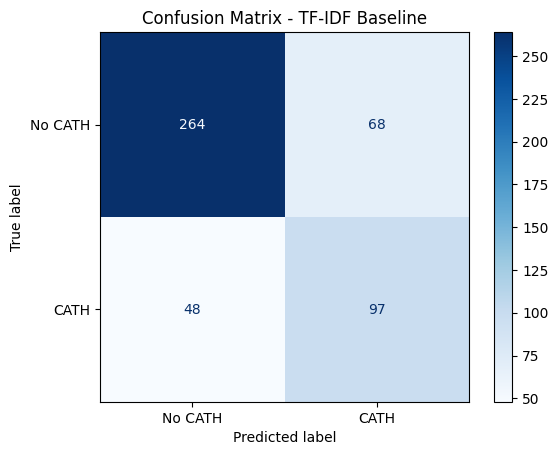

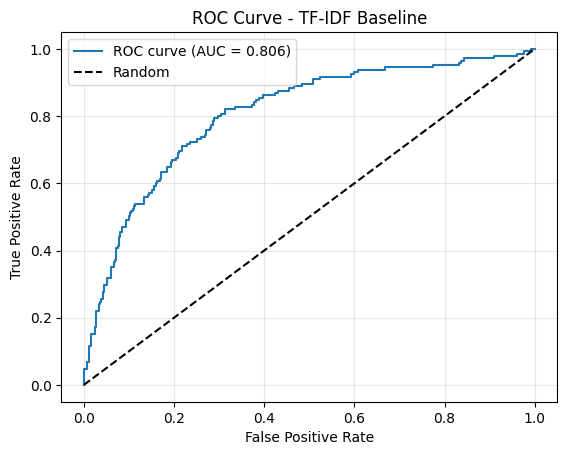

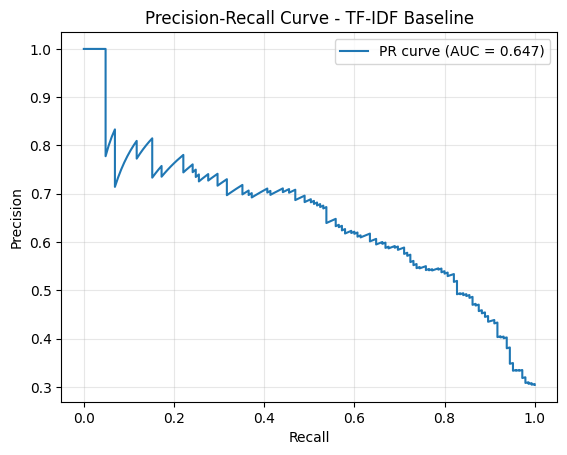


=== Summary Metrics ===
ROC-AUC: 0.806
PR-AUC: 0.647
Accuracy: 0.757

Results saved to results/


In [33]:
# Classification Report
print("\n Classification Report")
print(classification_report(test_df['cath_label'], y_pred_tfidf,
                            target_names=['No CATH', 'CATH']))

# Confusion Matrix
cm_tfidf = confusion_matrix(test_df['cath_label'], y_pred_tfidf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf,
                               display_labels=['No CATH', 'CATH'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - TF-IDF Baseline")
plt.show()

# ROC-AUC
roc_auc_tfidf = roc_auc_score(test_df['cath_label'], y_prob_tfidf)
fpr_tfidf, tpr_tfidf, _ = roc_curve(test_df['cath_label'], y_prob_tfidf)

plt.figure()
plt.plot(fpr_tfidf, tpr_tfidf, label=f'ROC curve (AUC = {roc_auc_tfidf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TF-IDF Baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall Curve
precision_tfidf, recall_tfidf, _ = precision_recall_curve(
    test_df['cath_label'], y_prob_tfidf
)
pr_auc_tfidf = auc(recall_tfidf, precision_tfidf)

plt.figure()
plt.plot(recall_tfidf, precision_tfidf,
         label=f'PR curve (AUC = {pr_auc_tfidf:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - TF-IDF Baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Save results
results_tfidf = pd.DataFrame({
    'true_label': test_df['cath_label'].values,
    'pred_label': y_pred_tfidf,
    'prob_CATH': y_prob_tfidf
})
results_tfidf.to_csv(os.path.join(RESULTS_DIR, 'tfidf_baseline_pred.csv'), index=False)

# Save metrics
with open(os.path.join(RESULTS_DIR, 'tfidf_baseline_metrics.txt'), 'w') as f:
    f.write("=== TF-IDF Baseline Results ===\n")
    f.write(f"ROC-AUC: {roc_auc_tfidf:.3f}\n")
    f.write(f"PR-AUC: {pr_auc_tfidf:.3f}\n")
    f.write(f"Accuracy: {(test_df['cath_label'].values == y_pred_tfidf).mean():.3f}\n\n")
    f.write(classification_report(test_df['cath_label'], y_pred_tfidf,
                                   target_names=['No CATH', 'CATH']))
    f.write(str(cm_tfidf))

# Print summary
print("\n=== Summary Metrics ===")
print(f"ROC-AUC: {roc_auc_tfidf:.3f}")
print(f"PR-AUC: {pr_auc_tfidf:.3f}")
print(f"Accuracy: {(test_df['cath_label'].values == y_pred_tfidf).mean():.3f}")
print(f"\nResults saved to {RESULTS_DIR}/")

In [34]:
# Important features
print("\n=== Top 20 Most Important Features ===")
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Get top features for predicting CATH
top_positive_idx = coefficients.argsort()[-20:][::-1]
print("\nTop features predicting CATH:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]:30s} {coefficients[idx]:8.4f}")

# Get top features predicting NO CATH
top_negative_idx = coefficients.argsort()[:20]
print("\nTop features predicting NO CATH:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:30s} {coefficients[idx]:8.4f}")


=== Top 20 Most Important Features ===

Top features predicting CATH:
  heparin                          1.9320
  cp                               1.1117
  stress                           1.0859
  sao2                             1.0481
  substernal                       1.0146
  inferior                         1.0111
  sinus                            1.0094
  substernal chest                 0.9976
  drip                             0.9943
  ntg                              0.9771
  heparin gtt                      0.9641
  aspirin                          0.9431
  free                             0.9411
  minutes                          0.9410
  femoral                          0.9338
  mb                               0.9109
  st                               0.9031
  avl                              0.8832
  ck                               0.8820
  angina                           0.8776

Top features predicting NO CATH:
  fibrillation                    -1.0461
  atrial fibr

## One Cycle: Model Config, DataLoader, Training + Eval

**Possible options for your GPU constraints:**

- **BioBERT** (https://huggingface.co/dmis-lab/biobert-v1.1): Trained on PubMed + PMC articles (general biomedical)
- **ClinicalBERT** (https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT): Trained on clinical notes (MIMIC data)
- **PubMedBERT** (https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext): similar to BioBERT but newer


In [35]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim import SGD
from sklearn.metrics import f1_score, precision_score, recall_score

import gc
torch.cuda.empty_cache()
gc.collect()

MODEL_NAME   = "emilyalsentzer/Bio_ClinicalBERT"
#MODEL_NAME   = "dmis-lab/biobert-v1.1"
NUM_LABELS   = 2
NUM_EPOCH    = 4
BATCH_SIZE   = 16
LR           = 2e-5
PATIENCE     = 3

In [36]:
device = 'cuda' if cuda.is_available() else 'cpu'

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS, torch_dtype="auto")
model = model.to(device)
model

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

### Tokenizer + Dataset

In [37]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize
train_encodings = tokenizer(
    train_df['model_input'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

test_encodings = tokenizer(
    test_df['model_input'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [38]:
class CATHDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CATHDataset(train_encodings, train_df['cath_label'].tolist())
test_dataset = CATHDataset(test_encodings, test_df['cath_label'].tolist())


In [39]:
# Create validation from training
from torch.utils.data import random_split
num_train = int(len(train_df)*0.8)

generator = torch.Generator().manual_seed(RSEED)
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset,
    [num_train, len(train_df)-num_train],
    generator=generator
    )

# Create dataloaders:
train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16)

### Training + Evaluation

In [40]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, verbose=False, mode='loss'):
        """
        Args:
            mode: 'loss' (minimize) or 'f1' (maximize)
        """
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.mode = mode
        self.best_score = None
        self.no_improvement_count = 0
        self.stop_training = False
        self.best_state_dict = None

    def check_early_stop(self, score, model):
        """
        Args:
            score: validation loss (if mode='loss') or F1 (if mode='f1')
        """
        if self.mode == 'loss':
            improved = (self.best_score is None or score < self.best_score - self.delta)
        else:  # mode == 'f1'
            improved = (self.best_score is None or score > self.best_score + self.delta)

        if improved:
            self.best_score = score
            self.no_improvement_count = 0
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if self.verbose:
                print(f"New best {self.mode}: {score:.4f}")
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print(f"No improvement for {self.patience} epochs. Stopping.")


In [41]:
def evaluate_with_mi_stratification(y_true_cath, y_pred_cath, y_prob_cath,
                                    mi_labels, experiment_name='model'):
    """
    Evaluate CATH prediction with MI stratification
    Critical: Performance on MI patients matters most (golden 90 minutes)

    Args:
        y_true_cath: True CATH labels
        y_pred_cath: Predicted CATH labels
        y_prob_cath: CATH probabilities
        mi_labels: MI diagnosis labels (0=no MI, 1=MI)
        experiment_name: Name for saving results

    Returns:
        Dictionary with stratified metrics
    """
    from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

    results = {}

    # === OVERALL METRICS ===
    print(f"\n{'='*60}")
    print(f"EVALUATION: {experiment_name}")
    print(f"{'='*60}")

    overall_auc = roc_auc_score(y_true_cath, y_prob_cath)
    overall_acc = (y_true_cath == y_pred_cath).mean()

    print(f"\n📊 Overall Performance:")
    print(f"   ROC-AUC: {overall_auc:.3f}")
    print(f"   Accuracy: {overall_acc:.3f}")
    print(classification_report(y_true_cath, y_pred_cath,
                                target_names=['No CATH', 'CATH']))

    results['overall'] = {
        'auc': overall_auc,
        'accuracy': overall_acc
    }

    # === MI PATIENTS (CRITICAL!) ===
    mi_mask = mi_labels == 1
    if mi_mask.sum() > 0:
        y_true_mi = y_true_cath[mi_mask]
        y_pred_mi = y_pred_cath[mi_mask]
        y_prob_mi = y_prob_cath[mi_mask]

        mi_auc = roc_auc_score(y_true_mi, y_prob_mi)
        mi_acc = (y_true_mi == y_pred_mi).mean()

        # Confusion matrix for MI patients
        cm_mi = confusion_matrix(y_true_mi, y_pred_mi)
        tn_mi, fp_mi, fn_mi, tp_mi = cm_mi.ravel()

        # Calculate critical metrics
        sensitivity_mi = tp_mi / (tp_mi + fn_mi) if (tp_mi + fn_mi) > 0 else 0
        specificity_mi = tn_mi / (tn_mi + fp_mi) if (tn_mi + fp_mi) > 0 else 0
        missed_mi_cath = fn_mi  # Patients who needed CATH but didn't get flagged

        print(f"\n MI Patients Performance (N={mi_mask.sum()}, CRITICAL!):")
        print(f"   ROC-AUC: {mi_auc:.3f}")
        print(f"   Accuracy: {mi_acc:.3f}")
        print(f"   Sensitivity (Recall for CATH): {sensitivity_mi:.3f} - SUPER IMPORTANT!")
        print(f"   Specificity: {specificity_mi:.3f}")
        print(f"   Missed CATH cases: {missed_mi_cath} (FALSE NEGATIVES - DANGEROUS!)")
        print(classification_report(y_true_mi, y_pred_mi,
                                    target_names=['No CATH', 'CATH']))

        results['mi_patients'] = {
            'auc': mi_auc,
            'accuracy': mi_acc,
            'sensitivity': sensitivity_mi,
            'specificity': specificity_mi,
            'missed_cath': int(missed_mi_cath),
            'n_samples': int(mi_mask.sum())
        }

    # === NON-MI PATIENTS ===
    non_mi_mask = mi_labels == 0
    if non_mi_mask.sum() > 0:
        y_true_non_mi = y_true_cath[non_mi_mask]
        y_pred_non_mi = y_pred_cath[non_mi_mask]
        y_prob_non_mi = y_prob_cath[non_mi_mask]

        non_mi_auc = roc_auc_score(y_true_non_mi, y_prob_non_mi)
        non_mi_acc = (y_true_non_mi == y_pred_non_mi).mean()

        print(f"\n Non-MI Patients Performance (N={non_mi_mask.sum()}):")
        print(f"   ROC-AUC: {non_mi_auc:.3f}")
        print(f"   Accuracy: {non_mi_acc:.3f}")
        print(classification_report(y_true_non_mi, y_pred_non_mi,
                                    target_names=['No CATH', 'CATH']))

        results['non_mi_patients'] = {
            'auc': non_mi_auc,
            'accuracy': non_mi_acc,
            'n_samples': int(non_mi_mask.sum())
        }

    # === RISK ANALYSIS ===
    print(f"\nClinical Risk Analysis:")

    # MI patients who need CATH but didn't get predicted
    mi_needs_cath = (mi_labels == 1) & (y_true_cath == 1)
    mi_missed = mi_needs_cath & (y_pred_cath == 0)

    # MI patients incorrectly predicted to need CATH
    mi_false_alarm = (mi_labels == 1) & (y_true_cath == 0) & (y_pred_cath == 1)

    print(f"   High Risk (MI + needs CATH): {mi_needs_cath.sum()} patients")
    print(f"   Missed (MI + needs CATH but not predicted): {mi_missed.sum()} patients")
    print(f"   False alarms (MI + doesn't need CATH but predicted): {mi_false_alarm.sum()} patients")

    if mi_needs_cath.sum() > 0:
        critical_recall = 1 - (mi_missed.sum() / mi_needs_cath.sum())
        print(f"   Critical Recall (caught MI+CATH cases): {critical_recall:.1%}")
        results['critical_recall'] = critical_recall

    return results

In [42]:
def evaluate_model(model, test_loader, device, test_df=None, test_indices=None,
                   experiment_name='model', results_dir=RESULTS_DIR):
    # Evaluation:
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
      for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].cpu().numpy() # true labels

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1) # predicted labels

        y_true.extend(labels)
        y_pred.extend(preds)
        y_prob.extend(probs[:, 1])

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # Classification report
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=['No CATH', 'CATH']))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CATH', 'CATH'])
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    # ROC–AUC
    roc_auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    # Precision–Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    plt.figure()
    plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall Curve')
    plt.legend()
    plt.show()

    # Save detailed predictions
    results_df = pd.DataFrame({
        'true_label': y_true,
        'pred_label': y_pred,
        'prob_CATH': y_prob
    })
    results_path = os.path.join(results_dir, f'{experiment_name}_pred.csv')
    results_df.to_csv(results_path, index=False)

    # Print out the summary
    print("\n=== Summary Metrics ===")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"PR-AUC : {pr_auc:.3f}")
    print(f"Accuracy: {(y_true == y_pred).mean():.3f}")

    # MI Stratified evaluation
    stratified_results = None
    if test_df is not None and 'mi_label' in test_df.columns:
        try:
            # Get MI labels in the SAME ORDER as test_loader predictions
            if test_indices is not None:
                mi_labels_test = test_df.loc[test_indices, 'mi_label'].values
            else:
                # Fallback: use test_df order (assumes same order as test_loader)
                mi_labels_test = test_df['mi_label'].values

            # Verify alignment
            if len(mi_labels_test) != len(y_true):
                print(f" WARNING: MI labels ({len(mi_labels_test)}) != predictions ({len(y_true)})")
                print("Skipping MI-stratified evaluation due to misalignment")
                stratified_results = None
            else:
                # Run stratified evaluation
                stratified_results = evaluate_with_mi_stratification(
                    np.array(y_true),
                    np.array(y_pred),
                    np.array(y_prob),
                    mi_labels_test,
                    experiment_name
                )
        except Exception as e:
            print(f"\nWarning: Could not run MI-stratified evaluation: {e}")
            stratified_results = None
    else:
        print("\nNote: 'mi_label' column not provided. Skipping MI-stratified evaluation.")

    metrics_path = os.path.join(results_dir, f'{experiment_name}_metrics.txt')
    with open(metrics_path, "w") as f:
        f.write(f"=== Summary Metrics ({experiment_name}) ===\n")
        f.write(f"ROC-AUC: {roc_auc:.3f}\n")
        f.write(f"PR-AUC : {pr_auc:.3f}\n")
        f.write(f"Accuracy: {(y_true == y_pred).mean():.3f}\n\n")
        f.write(classification_report(y_true, y_pred, target_names=['No CATH', 'CATH']))
        f.write("\n\nConfusion Matrix:\n")
        f.write(str(confusion_matrix(y_true, y_pred)))

        # Write stratified results if available
        if stratified_results:
            f.write("\n\n=== MI-Stratified Results ===\n")
            f.write(json.dumps(stratified_results, indent=2))

    return y_true, y_pred, y_prob, stratified_results

In [43]:
import json

def one_cycle(model, train_loader, val_loader, test_loader,
              train_labels,
              test_df=None,
              test_indices=None,
              num_epochs=NUM_EPOCH, device=device,
              learning_rate=LR, patience=PATIENCE,
              checkpoint_dir=CHECKPOINTS_DIR, results_dir=RESULTS_DIR,
              experiment_name='baseline'):
    """
    Args:
        model: PyTorch model to train
        train_loader, val_loader: DataLoaders
        num_epochs: Number of training epochs
        device: 'cuda' or 'cpu'
        train_df: Training dataframe (for class weights)
        learning_rate: Learning rate
        patience: Early stopping patience
        checkpoint_dir: Where to save checkpoints
        experiment_name: Name for this experiment (e.g., 'baseline', 'lora', 'kg')

    Returns:
        model: Trained model
        history: Dict with train/val losses and metrics
    """

    # Calculate class weights from training labels
    train_labels_array = np.array(train_labels)
    class_0 = (train_labels_array == 0).sum()
    class_1 = (train_labels_array == 1).sum()
    total = class_0 + class_1

    if class_0 > 0 and class_1 > 0:
        class_weights = torch.tensor([total/(2*class_0), total/(2*class_1)], dtype=torch.float).to(device)
    else:
        print("Warning: Class imbalance issue detected, using equal weights")
        class_weights = torch.tensor([1.0, 1.0], dtype=torch.float).to(device)

    print(f"Class weights: No CATH={class_weights[0]:.3f}, CATH={class_weights[1]:.3f}")

    # Define the loss function:
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights).to(device)

    #optimizer:
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3) # ADJUST

    #scheduler:
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=learning_rate*2.5,
        steps_per_epoch=len(train_loader),
        epochs=num_epochs,
        pct_start=0.1, #warmup quicker
        anneal_strategy='cos'
    )

    # Initialize early stopping
    early_stopping = EarlyStopping(patience=patience, delta=0, verbose=True, mode='f1')

    # History tracking
    history = {
          'train_loss': [],
          'val_loss': [],
          'val_f1': [],
          'val_precision': [],
          'val_recall': []
    }


    for epoch in range(num_epochs):
      model.train()
      train_losses = []
      for batch in tqdm(train_loader,desc=f"Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()

        outputs = model(
          input_ids      = batch['input_ids'].to(device),
          attention_mask = batch['attention_mask'].to(device),
          labels         = batch['labels'].to(device)
        )

        loss = criterion(outputs.logits, batch['labels'].to(device))
        loss.backward()
        train_losses.append(loss.item())

        # Gradient clipping (if needed)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

      history['train_loss'].append(np.mean(train_losses))

      # Validation phase after each epoch
      model.eval()
      y_true, y_pred = [], []
      val_loss = 0.0
      total = 0

      with torch.no_grad():
          for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
              val_outputs = model(
                  input_ids=batch['input_ids'].to(device),
                  attention_mask=batch['attention_mask'].to(device),
                  labels=batch['labels'].to(device)
              )

              vloss = criterion(val_outputs.logits, batch['labels'].to(device))
              val_loss += vloss.item() * batch['labels'].size(0)
              total += batch['labels'].size(0)

              #prediction
              _, predicted = torch.max(val_outputs.logits, 1)

              y_pred.extend(predicted.cpu().numpy())
              y_true.extend(batch['labels'].cpu().numpy())

      history['val_loss'].append(val_loss / total)
      history['val_f1'].append(f1_score(y_true, y_pred, average='macro'))
      history['val_precision'].append(precision_score(y_true, y_pred, average='macro'))
      history['val_recall'].append(recall_score(y_true, y_pred, average='macro'))


      print(f"Epoch {epoch+1}: Train Loss = {history['train_loss'][-1]:.3f}, "
            f"Val Loss: {history['val_loss'][-1]:.3f}, "
            f"F1: {history['val_f1'][-1]:.2f}, "
            f"Precision: {history['val_precision'][-1]:.2f}, "
            f"Recall: {history['val_recall'][-1]:.2f}")


      # Early stopping check
      early_stopping.check_early_stop(history['val_f1'][-1], model)
      if early_stopping.stop_training:
          print(f"Stopping early at epoch {epoch+1}")
          break

    # Plotting the loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Train and Validation Loss Curves')
    plt.show()

    print('Finished Training')

    # Load best model after EarlyStopping
    if early_stopping.best_state_dict is not None:
        model.load_state_dict(early_stopping.best_state_dict)
        print("Loaded best model from early stopping")

        # Save only the final best model
        checkpoint_path = os.path.join(checkpoint_dir, f'{experiment_name}_best.pt')
        torch.save({
            'best_score': early_stopping.best_score,  # ← FIXED
            'model_state_dict': model.state_dict(),
            'mode': 'f1'  # ← Add this for clarity
        }, checkpoint_path)

    y_true, y_pred, y_prob, stratified_results = evaluate_model(
        model=model,
        test_loader=test_loader,
        device=device,
        test_df=test_df,
        test_indices=test_indices,
        experiment_name=experiment_name,
        results_dir=results_dir
    )


    return model, history, y_true, y_pred, y_prob, stratified_results

## LoRA

In [44]:
# from peft import LoraConfig, get_peft_model, TaskType

# lora_r = 8
# scaling_factor = 2
# lora_alpha = scaling_factor * lora_r

# def create_lora_model(model_name, num_labels, lora_r=lora_r, lora_alpha=lora_alpha, lora_dropout=0.1):
#     """
#     Create a RoBERTa model with LoRA adapters

#     Args:
#         model_name: Base model name (e.g., 'roberta-base')
#         num_labels: Number of classification labels
#         lora_r: LoRA rank
#         lora_alpha: LoRA alpha parameter
#         lora_dropout: Dropout for LoRA layers

#     Returns:
#         model: LoRA-enhanced model
#     """
#     # Load base model
#     base_model = AutoModelForSequenceClassification.from_pretrained(
#         model_name,
#         num_labels=num_labels
#     )

#     # LoRA configuration
#     lora_config = LoraConfig(
#         task_type=TaskType.SEQ_CLS,
#         r=lora_r,  # Rank - lower = fewer parameters
#         lora_alpha=lora_alpha,  # Scaling factor
#         lora_dropout=lora_dropout,
#         target_modules=["query", "value"],  # Which attention layers to adapt
#         bias="none"
#     )

#     # Apply LoRA
#     model = get_peft_model(base_model, lora_config)
#     model.print_trainable_parameters()  # Shows how many params are trainable

#     return model

# # Usage:
# # lora_r: [4, 8, 16, 32] - lower = faster/smaller, higher = more capacity
# model_lora = create_lora_model(MODEL_NAME, NUM_LABELS, lora_r=8, lora_alpha=16)
# model_lora = model_lora.to(device)

# # Train with LoRA
# # learning_rate: Try [1e-4, 3e-4, 5e-4] - higher than full fine-tuning
# trained_lora_model, lora_history, y_true, y_pred, y_prob = one_cycle(
#     model=model_lora,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     test_loader=test_loader,
#     learning_rate=3e-4,  # Higher LR for LoRA
#     experiment_name='lora'
# )

## Baseline vs. KG (ECG only, TF-IDF enhanced, Custom)

In [45]:
## Knowledge Graph Configuration and Utilities

class KGConfig:
    """Configuration for different KG variants"""

    @staticmethod
    def simple_ecg_only():
        """Original simple KG - ECG findings only"""
        return {
            'name': '2_kg_ecg',
            'patterns': {
                'ecg': ['st_elevation', 'infarct', 'ischemia', 'abnormal_ecg']
            },
            'use_troponin': False,
            'use_symptoms': False,
            'use_tfidf': False
        }

    @staticmethod
    def enhanced_with_tfidf():
        """Enhanced KG with TF-IDF patterns"""
        return {
            'name': '3_kg_tfidf',
            'patterns': {
                'ecg': ['st_elevation', 'st_depression', 't_wave_abnormal', 'q_waves',
                        'lbbb', 'afib', 'infarct', 'ischemia', 'abnormal_ecg', 'normal_ecg'],
                'symptoms': ['substernal_chest', 'angina', 'radiation_pain'],
                'medications': ['acute_meds', 'diaphoresis'],
                'transfer': ['transferred', 'outside_hospital'],
                'alternative_dx': ['afib_primary', 'pericarditis', 'pulmonary_embolism',
                                  'heart_failure', 'effusion']
            },
            'use_troponin': True,
            'use_symptoms': True,
            'use_tfidf': True,
            'top_k_patterns': 7
        }

    @staticmethod
    def custom(ecg_patterns=None, use_troponin=True, use_symptoms=True, use_tfidf=False):
        """Create custom KG configuration"""
        return {
            'name': 'custom',
            'patterns': {
                'ecg': ecg_patterns or ['st_elevation', 'infarct', 'ischemia', 'abnormal_ecg']
            },
            'use_troponin': use_troponin,
            'use_symptoms': use_symptoms,
            'use_tfidf': use_tfidf
        }



In [46]:
def extract_patterns_from_patient(row, config, precomputed_text=None):
    """
    Shared pattern extraction logic for both KG building and feature engineering

    Args:
        row: Patient data row
        config: KG configuration
        precomputed_text: Optional pre-computed text fields (for efficiency)

    Returns:
        Dictionary of matched patterns
    """
    if precomputed_text:
        ecg_findings = precomputed_text['ecg']
        full_text = precomputed_text['full']
    else:
        ecg_findings = str(row['ecg_text']).lower()
        chief_complaint = str(row['chief_complaint']).lower()
        hpi = str(row['HPI']).lower()
        physical_exam = str(row['physical_exam']).lower()
        full_text = f"{chief_complaint} {hpi} {physical_exam} {ecg_findings}"

    troponin = row['troponin_status']
    patterns = {}

    # === ECG PATTERNS ===
    if 'ecg' in config['patterns']:
        ecg_map = {
            'st_elevation': ('st elevation' in ecg_findings or 'stemi' in ecg_findings or
                            'st segment elevation' in ecg_findings),
            'st_depression': 'st depression' in ecg_findings or 'st segment depression' in ecg_findings,
            't_wave_abnormal': ('t wave inversion' in ecg_findings or 't wave abnormality' in ecg_findings or
                               'inverted t' in ecg_findings),
            'q_waves': 'q wave' in ecg_findings or 'pathological q' in ecg_findings,
            'lbbb': 'lbbb' in ecg_findings or 'left bundle branch block' in ecg_findings,
            'afib': 'atrial fibrillation' in ecg_findings or 'afib' in ecg_findings or 'a fib' in ecg_findings,
            'infarct': 'infarct' in ecg_findings and 'no infarct' not in ecg_findings,
            'ischemia': (('ischemia' in ecg_findings or 'ischemic' in ecg_findings) and
                       'no ischemia' not in ecg_findings),
            'abnormal_ecg': 'abnormal ecg' in ecg_findings,
            'normal_ecg': 'normal ecg' in ecg_findings or 'no acute' in ecg_findings,
        }
        for pattern in config['patterns']['ecg']:
            if pattern in ecg_map:
                patterns[pattern] = ecg_map[pattern]

    # === TROPONIN ===
    if config.get('use_troponin', False):
        patterns['troponin_elevated'] = troponin == 'abnormal'
        patterns['troponin_normal'] = troponin == 'normal'
        patterns['troponin_not_tested'] = troponin == 'not_tested'

    # === SYMPTOMS ===
    if config.get('use_symptoms', False):
        chief_complaint = str(row['chief_complaint']).lower() if not precomputed_text else full_text
        patterns['chest_pain'] = ('chest pain' in chief_complaint or 'chest discomfort' in chief_complaint or
                                 'angina' in chief_complaint)
        patterns['shortness_breath'] = ('shortness' in chief_complaint or 'dyspnea' in chief_complaint or
                                       'sob' in chief_complaint)

    # === TF-IDF PATTERNS ===
    if config.get('use_tfidf', False):
        if 'medications' in config['patterns']:
            # Note: heparin/plavix removed by leakage cleaning, now focus on presentation meds
            patterns['acute_meds'] = 'aspirin' in full_text or 'nitroglycerin' in full_text or 'ntg' in full_text
            patterns['diaphoresis'] = ('diaphoresis' in full_text or 'diaphoretic' in full_text or
                                      'sweating' in full_text)
            # Note: Aspirin/NTG are given before cath (for ACS symptoms), while heparin/plavix are given after cath.

        if 'symptoms' in config['patterns']:
            patterns['substernal_chest'] = 'substernal' in full_text and 'chest' in full_text
            patterns['angina'] = 'angina' in full_text
            patterns['radiation_pain'] = ('radiating' in full_text or 'radiation' in full_text) and ('arm' in full_text or 'jaw' in full_text)

        if 'transfer' in config['patterns']:
            patterns['transferred'] = 'transferred' in full_text or 'transfer' in full_text
            patterns['outside_hospital'] = 'osh' in full_text or 'outside hospital' in full_text

        if 'alternative_dx' in config['patterns']:
            patterns['afib_primary'] = (('afib' in full_text or 'atrial fibrillation' in full_text or
                                        'atrial flutter' in full_text) and 'st elevation' not in ecg_findings)
            patterns['pericarditis'] = 'pericarditis' in full_text or 'pericardial' in full_text
            patterns['pulmonary_embolism'] = 'pe' in full_text or 'pulmonary embolism' in full_text
            patterns['heart_failure'] = 'lasix' in full_text or 'furosemide' in full_text
            patterns['effusion'] = 'effusion' in full_text and 'pericardial' in full_text

    return patterns

In [47]:
def build_kg_from_config(train_df, train_indices, config):
    """
    Build KG ONLY from actual training data (excluding validation)

    Args:
        train_df: Full training DataFrame
        train_indices: Indices of TRUE training samples (excluding validation)
        config: KG configuration
    """
    kg = {}

    # Pre-compute text fields
    train_only_df = train_df.loc[train_indices].copy()
    train_only_df['_full_text'] = (
        train_only_df['chief_complaint'].astype(str).str.lower() + ' ' +
        train_only_df['HPI'].astype(str).str.lower() + ' ' +
        train_only_df['physical_exam'].astype(str).str.lower() + ' ' +
        train_only_df['ecg_text'].astype(str).str.lower()
    )
    train_only_df['_ecg_lower'] = train_only_df['ecg_text'].astype(str).str.lower()

    for idx, row in train_only_df.iterrows():
        patterns = extract_patterns_from_patient(
            row,
            config,
            precomputed_text={
                'ecg': row['_ecg_lower'],
                'full': row['_full_text']
            }
        )

        # Update KG statistics
        for pattern_name, pattern_found in patterns.items():
            if pattern_found:
                if pattern_name not in kg:
                    kg[pattern_name] = {'cath_count': 0, 'total': 0}
                kg[pattern_name]['total'] += 1
                if row['cath_label'] == 1:
                    kg[pattern_name]['cath_count'] += 1

    # Calculate probabilities
    for pattern in kg:
        total = kg[pattern]['total']
        cath_count = kg[pattern]['cath_count']
        kg[pattern]['cath_prob'] = (cath_count + 1) / (total + 2)  # Laplace smoothing
        kg[pattern]['confidence'] = min(total / 50, 1.0)

    return kg


In [48]:
def add_kg_features_from_config(row, kg, config):
    """
    Feature adder to train data for any configuration

    Args:
        row: DataFrame row
        kg: Knowledge graph dictionary
        config: Configuration dictionary

    Returns:
        text: Enhanced text with KG features
    """

    # Use shared pattern extraction
    patterns = extract_patterns_from_patient(row, config)

    # Build KG feature string
    matched_patterns = []
    for pattern_name, is_present in patterns.items():
        if is_present and pattern_name in kg:
            prob = kg[pattern_name]['cath_prob']
            conf = kg[pattern_name]['confidence']
            if conf > 0.5:
                matched_patterns.append(f"{pattern_name}:{prob:.2f}")

    # Sort by probability
    matched_patterns.sort(key=lambda x: float(x.split(':')[1]), reverse=True)

    # Build KG text
    top_k = config.get('top_k_patterns', 5)
    kg_text = ""
    if matched_patterns:
        kg_text = f" [KG: {', '.join(matched_patterns[:top_k])}]"

    # Assemble input
    text = f"History: {row['HPI']} | "
    text += f"Chief Complaint: {row['chief_complaint']} | "
    text += f"Physical Exam: {row['physical_exam']} | "
    text += f"ECG: {row['ecg_text']} | "
    text += f"Troponin: {row['troponin_status']}"
    text += kg_text

    return text

In [49]:
def train_kg_model(train_df, test_df, config, tokenizer, device,
                   num_epochs=4, learning_rate=2e-5, patience=3,
                   batch_size=16, dropout=0.1):
    """
    Complete training pipeline for any KG configuration

    Args:
        train_df, test_df: DataFrames
        config: KG configuration dictionary
        tokenizer: Pre-loaded tokenizer
        device: 'cuda' or 'cpu'
        ... training hyperparameters

    Returns:
        Tuple of (trained_model, history, y_true, y_pred, y_prob, kg)
    """
    import gc
    torch.cuda.empty_cache()
    gc.collect()

    print(f"\n{'='*60}")
    print(f"Training: {config['name']}")

    # Build KG
    print(f"\n{'='*60}")
    print(f"Training: {config['name']}")
    print(f"{'='*60}")
    print("Building knowledge graph...")
    kg = build_kg_from_config(train_df, train_indices, config)

    # Show statistics
    print(f"\nKG Statistics:")
    print(f"Total patterns: {len(kg)}")
    sorted_patterns = sorted(kg.items(), key=lambda x: x[1]['cath_prob'], reverse=True)
    print("\nTop 10 patterns by CATH risk:")
    for pattern, stats in sorted_patterns[:10]:
        print(f"  {pattern:25s}: {stats['cath_prob']:.2%} (n={stats['total']:4d}, conf={stats['confidence']:.2f})")

    # Enhance features
    print("\nEnhancing features...")
    train_texts = []
    for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Train"):
        train_texts.append(add_kg_features_from_config(row, kg, config))

    test_texts = []
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test"):
        test_texts.append(add_kg_features_from_config(row, kg, config))

    # Optional: Save for debugging
    train_df[f'model_input_{config["name"]}'] = train_texts
    test_df[f'model_input_{config["name"]}'] = test_texts

    # Token analysis
    print("\nToken length analysis...")
    sample_texts = train_df[f'model_input_{config["name"]}'].head(10).tolist()
    token_lens = [len(tokenizer.tokenize(t)) for t in sample_texts]
    print(f"  Mean: {np.mean(token_lens):.0f}, Max: {max(token_lens)}, "
          f"Truncated: {sum(1 for x in token_lens if x > 512)}/10")

    # Tokenize
    train_encodings = tokenizer(
        train_texts,
        truncation=True, padding=True, max_length=512
    )
    test_encodings = tokenizer(
        test_texts,
        truncation=True, padding=True, max_length=512
    )

    # Create datasets
    train_dataset = CATHDataset(train_encodings, train_df['cath_label'].tolist())
    test_dataset = CATHDataset(test_encodings, test_df['cath_label'].tolist())

    # Get the row positions in the current train_df that match our fixed indices
    train_positions = [i for i, idx in enumerate(train_df.index) if idx in train_indices]
    val_positions = [i for i, idx in enumerate(train_df.index) if idx in val_indices]

    from torch.utils.data import Subset
    train_subset = Subset(train_dataset, train_positions)
    val_subset = Subset(train_dataset, val_positions)

    # Dataloaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Clear memory
    gc.collect()
    torch.cuda.empty_cache()

    # Initialize model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    ).to(device)

    # Check for existing checkpoint
    checkpoint_path = os.path.join('checkpoints', f'{config["name"]}_best.pt')
    if os.path.exists(checkpoint_path):
        print(f"\n🔄 Found existing checkpoint: {checkpoint_path}")
        print("Loading model and skipping training...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])

        y_true, y_pred, y_prob, stratified_results = evaluate_model(
            model=model,
            test_loader=test_loader,
            device=device,
            test_df=test_df,
            test_indices=FIXED_TEST_INDICES,
            experiment_name=config["name"],
            results_dir=RESULTS_DIR
        )
        history = None

        print("Evaluation complete using loaded checkpoint")
        return model, history, y_true, y_pred, y_prob, kg, stratified_results
    else:
        print(f"\n No checkpoint found. Training from scratch...")

        # Train
        # Get training labels for class weights (safer method)
        train_labels_for_weights = []
        for idx in train_subset.indices:
            train_labels_for_weights.append(train_dataset.labels[idx])


        trained_model, history, y_true, y_pred, y_prob, stratified_results = one_cycle(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            train_labels=train_labels_for_weights,
            test_df=test_df,
            test_indices=FIXED_TEST_INDICES,
            num_epochs=num_epochs,
            learning_rate=learning_rate,
            patience=patience,
            experiment_name=config['name']
        )

        return trained_model, history, y_true, y_pred, y_prob, kg, stratified_results

EXPERIMENT 1: BASELINE (No KG)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 No checkpoint found. Training from scratch...
Class weights: No CATH=0.720, CATH=1.638


Epoch 1/4:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 1/4:   0%|          | 0/24 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 4/4:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 4/4:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.703, Val Loss: 0.693, F1: 0.41, Precision: 0.35, Recall: 0.50
No improvement for 3 epochs. Stopping.
Stopping early at epoch 4


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


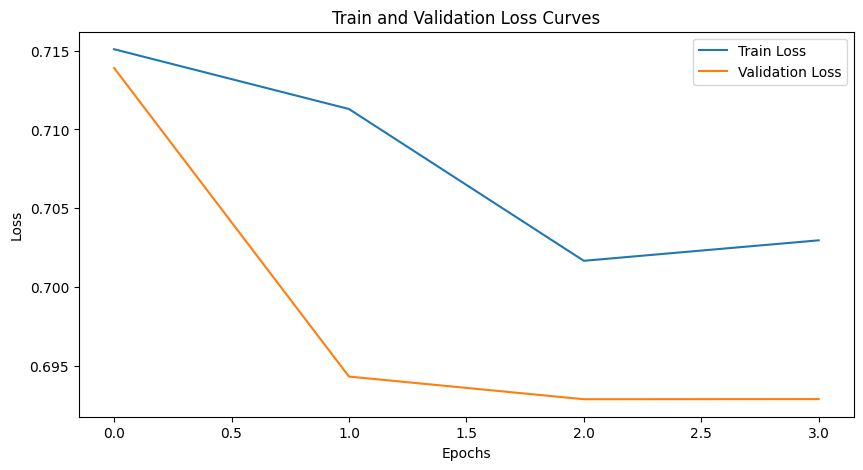

Finished Training
Loaded best model from early stopping


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


=== Classification Report ===
              precision    recall  f1-score   support

     No CATH       0.70      1.00      0.82       332
        CATH       0.00      0.00      0.00       145

    accuracy                           0.70       477
   macro avg       0.35      0.50      0.41       477
weighted avg       0.48      0.70      0.57       477



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


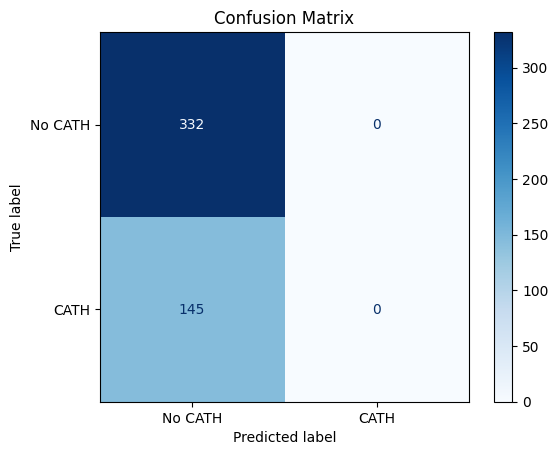

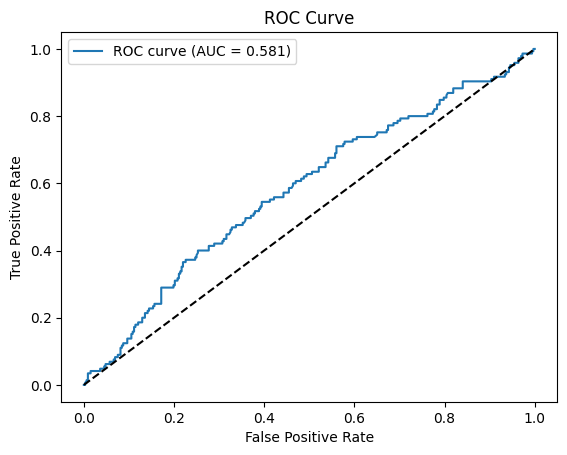

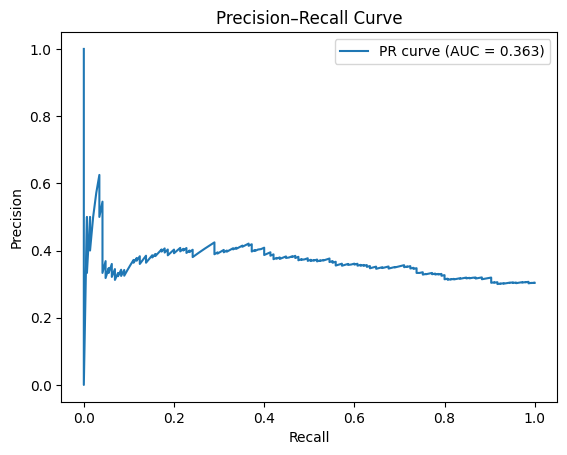


=== Summary Metrics ===
ROC-AUC: 0.581
PR-AUC : 0.363
Accuracy: 0.696

EVALUATION: 1_no_kg

📊 Overall Performance:
   ROC-AUC: 0.581
   Accuracy: 0.696
              precision    recall  f1-score   support

     No CATH       0.70      1.00      0.82       332
        CATH       0.00      0.00      0.00       145

    accuracy                           0.70       477
   macro avg       0.35      0.50      0.41       477
weighted avg       0.48      0.70      0.57       477


 MI Patients Performance (N=112, CRITICAL!):
   ROC-AUC: 0.584
   Accuracy: 0.321
   Sensitivity (Recall for CATH): 0.000 - SUPER IMPORTANT!
   Specificity: 1.000
   Missed CATH cases: 76 (FALSE NEGATIVES - DANGEROUS!)
              precision    recall  f1-score   support

     No CATH       0.32      1.00      0.49        36
        CATH       0.00      0.00      0.00        76

    accuracy                           0.32       112
   macro avg       0.16      0.50      0.24       112
weighted avg       0.10     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [50]:








from torch.utils.data import Subset

# Experiment 1: Baseline (No Knowledge Graph)

print("EXPERIMENT 1: BASELINE (No KG)")
print("="*80)

# Use original model_input (without KG features)
train_encodings_baseline = tokenizer(
    train_df['model_input'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

test_encodings_baseline = tokenizer(
    test_df['model_input'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

train_dataset_baseline = CATHDataset(train_encodings_baseline, train_df['cath_label'].tolist())
test_dataset_baseline = CATHDataset(test_encodings_baseline, test_df['cath_label'].tolist())

# Use fixed splits
train_positions = [i for i, idx in enumerate(train_df.index) if idx in train_indices]
val_positions = [i for i, idx in enumerate(train_df.index) if idx in val_indices]

train_subset_bl = Subset(train_dataset_baseline, train_positions)
val_subset_bl = Subset(train_dataset_baseline, val_positions)

train_loader_bl = DataLoader(train_subset_bl, batch_size=16, shuffle=True)
val_loader_bl = DataLoader(val_subset_bl, batch_size=16, shuffle=False)
test_loader_bl = DataLoader(test_dataset_baseline, batch_size=16)

# Train
model_baseline = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
).to(device)

checkpoint_path = os.path.join('checkpoints', '1_no_kg_best.pt')
if os.path.exists(checkpoint_path):
    print(f"\nFound existing checkpoint: {checkpoint_path}")
    print("Loading model and skipping training...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_baseline.load_state_dict(checkpoint['model_state_dict'])

    # Run evaluation only
    y_true_bl, y_pred_bl, y_prob_bl, strat_bl = evaluate_model(
        model=model_baseline,
        test_loader=test_loader_bl,
        device=device,
        test_df=test_df,
        test_indices=FIXED_TEST_INDICES,
        experiment_name='1_no_kg',
        results_dir=RESULTS_DIR
    )
    history_bl = None
    print("Evaluation complete using loaded checkpoint")
else:
    print(f"\n No checkpoint found. Training from scratch...")
    train_labels_baseline = [train_dataset_baseline.labels[i] for i in train_subset_bl.indices]

    model_bl, history_bl, y_true_bl, y_pred_bl, y_prob_bl, strat_bl = one_cycle(
        model=model_baseline,
        train_loader=train_loader_bl,
        val_loader=val_loader_bl,
        test_loader=test_loader_bl,
        train_labels=train_labels_baseline,
        test_df=test_df,
        test_indices=FIXED_TEST_INDICES,
        num_epochs=4,
        learning_rate=2e-5,
        patience=3,
        experiment_name='1_no_kg'
    )


In [51]:
# Clear memory
import gc

if 'model_bl' in locals():
    del model_bl
torch.cuda.empty_cache()
gc.collect()

14479


Training: 2_kg_ecg

Training: 2_kg_ecg
Building knowledge graph...

KG Statistics:
Total patterns: 4

Top 10 patterns by CATH risk:
  ischemia                 : 41.57% (n= 419, conf=1.00)
  abnormal_ecg             : 41.10% (n= 380, conf=1.00)
  st_elevation             : 40.15% (n= 135, conf=1.00)
  infarct                  : 38.58% (n= 449, conf=1.00)

Enhancing features...


Train:   0%|          | 0/1904 [00:00<?, ?it/s]

Test:   0%|          | 0/477 [00:00<?, ?it/s]


Token length analysis...
  Mean: 963, Max: 1596, Truncated: 10/10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch 3/4:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.528, Val Loss: 0.602, F1: 0.68, Precision: 0.68, Recall: 0.70
New best f1: 0.6847


Epoch 4/4:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 4/4:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.402, Val Loss: 0.636, F1: 0.70, Precision: 0.69, Recall: 0.70
New best f1: 0.6986


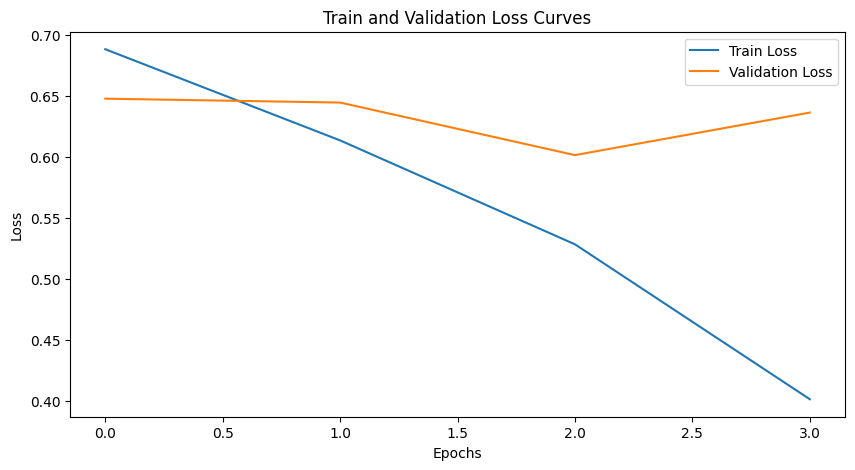

Finished Training
Loaded best model from early stopping


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


=== Classification Report ===
              precision    recall  f1-score   support

     No CATH       0.81      0.77      0.79       332
        CATH       0.53      0.58      0.55       145

    accuracy                           0.71       477
   macro avg       0.67      0.68      0.67       477
weighted avg       0.72      0.71      0.72       477



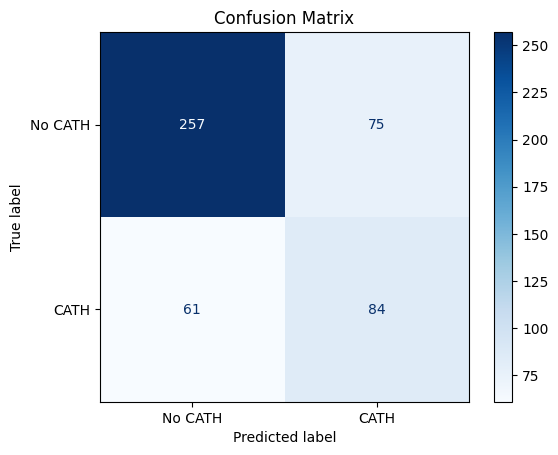

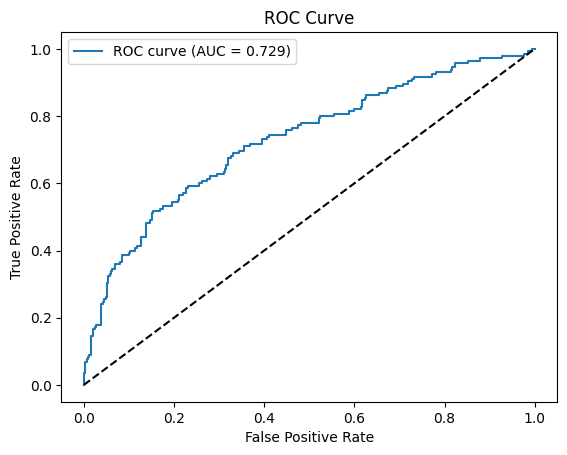

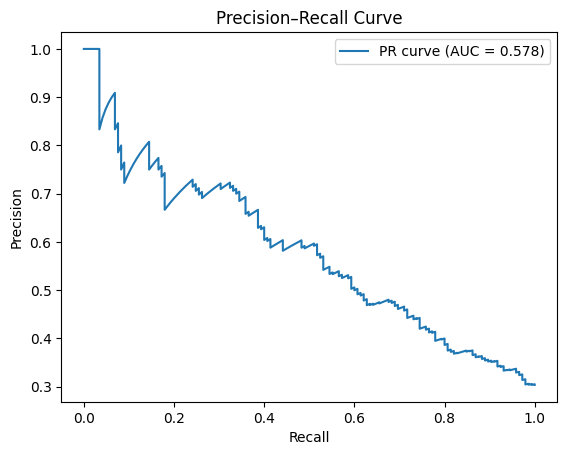


=== Summary Metrics ===
ROC-AUC: 0.729
PR-AUC : 0.578
Accuracy: 0.715

EVALUATION: 2_kg_ecg

📊 Overall Performance:
   ROC-AUC: 0.729
   Accuracy: 0.715
              precision    recall  f1-score   support

     No CATH       0.81      0.77      0.79       332
        CATH       0.53      0.58      0.55       145

    accuracy                           0.71       477
   macro avg       0.67      0.68      0.67       477
weighted avg       0.72      0.71      0.72       477


 MI Patients Performance (N=112, CRITICAL!):
   ROC-AUC: 0.633
   Accuracy: 0.634
   Sensitivity (Recall for CATH): 0.711 - SUPER IMPORTANT!
   Specificity: 0.472
   Missed CATH cases: 22 (FALSE NEGATIVES - DANGEROUS!)
              precision    recall  f1-score   support

     No CATH       0.44      0.47      0.45        36
        CATH       0.74      0.71      0.72        76

    accuracy                           0.63       112
   macro avg       0.59      0.59      0.59       112
weighted avg       0.64    

17399

In [52]:
# Train simple KG (ECG only)
config_simple = KGConfig.simple_ecg_only()
model_simple, history_simple, y_true_simple, y_pred_simple, y_prob_simple, kg_simple, strat_simple = train_kg_model(
    train_df, test_df, config_simple, tokenizer, device
)

if 'model_simple' in locals():
    del model_simple
torch.cuda.empty_cache()
gc.collect()


Training: 3_kg_tfidf

Training: 3_kg_tfidf
Building knowledge graph...

KG Statistics:
Total patterns: 26

Top 10 patterns by CATH risk:
  substernal_chest         : 55.67% (n= 192, conf=1.00)
  angina                   : 54.14% (n= 131, conf=1.00)
  st_depression            : 50.52% (n=  95, conf=1.00)
  acute_meds               : 47.04% (n= 421, conf=1.00)
  q_waves                  : 47.00% (n=  98, conf=1.00)
  diaphoresis              : 45.05% (n= 382, conf=1.00)
  outside_hospital         : 43.67% (n= 156, conf=1.00)
  radiation_pain           : 43.19% (n= 211, conf=1.00)
  t_wave_abnormal          : 42.17% (n=  81, conf=1.00)
  ischemia                 : 41.57% (n= 419, conf=1.00)

Enhancing features...


Train:   0%|          | 0/1904 [00:00<?, ?it/s]

Test:   0%|          | 0/477 [00:00<?, ?it/s]


Token length analysis...
  Mean: 1008, Max: 1639, Truncated: 10/10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch 3/4:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.557, Val Loss: 0.577, F1: 0.69, Precision: 0.69, Recall: 0.71


Epoch 4/4:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 4/4:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.434, Val Loss: 0.605, F1: 0.68, Precision: 0.67, Recall: 0.69


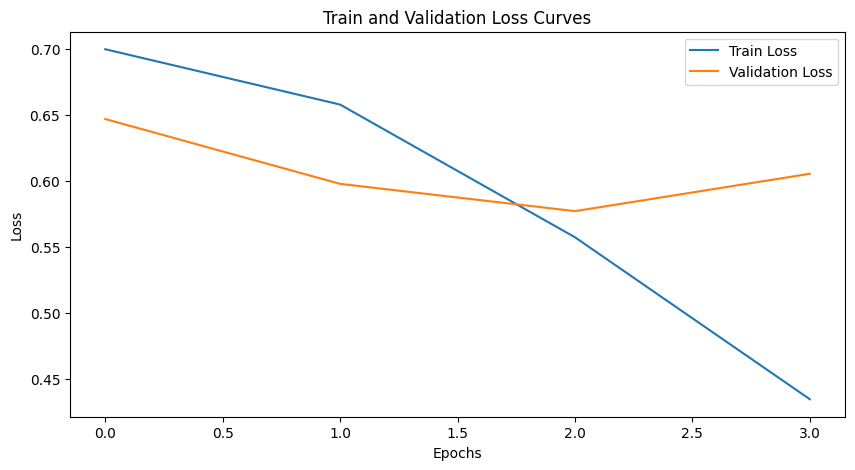

Finished Training
Loaded best model from early stopping


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


=== Classification Report ===
              precision    recall  f1-score   support

     No CATH       0.82      0.85      0.83       332
        CATH       0.62      0.57      0.59       145

    accuracy                           0.76       477
   macro avg       0.72      0.71      0.71       477
weighted avg       0.76      0.76      0.76       477



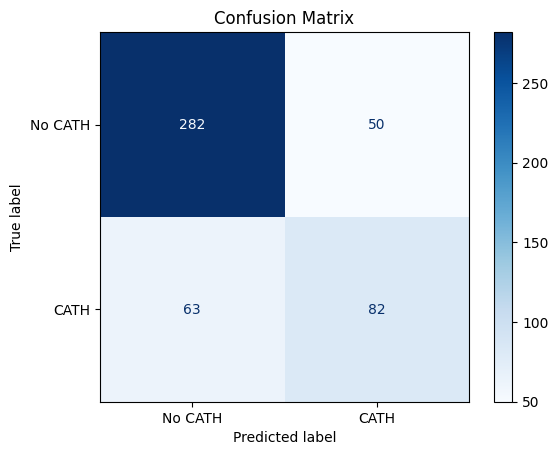

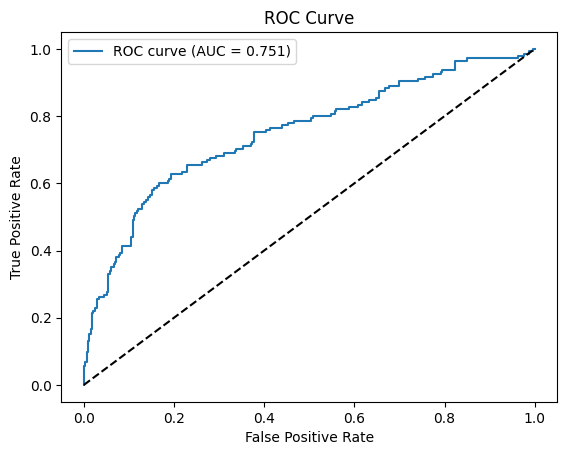

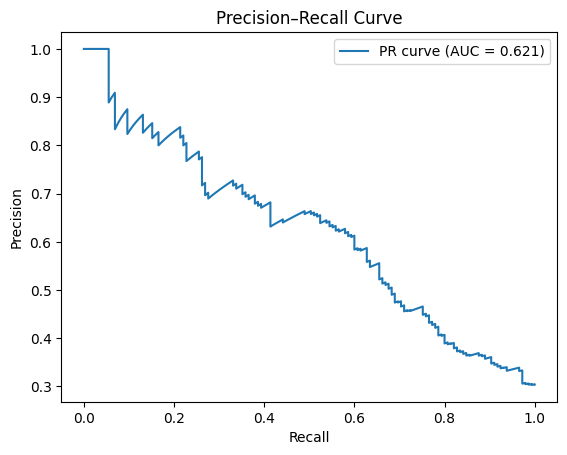


=== Summary Metrics ===
ROC-AUC: 0.751
PR-AUC : 0.621
Accuracy: 0.763

EVALUATION: 3_kg_tfidf

📊 Overall Performance:
   ROC-AUC: 0.751
   Accuracy: 0.763
              precision    recall  f1-score   support

     No CATH       0.82      0.85      0.83       332
        CATH       0.62      0.57      0.59       145

    accuracy                           0.76       477
   macro avg       0.72      0.71      0.71       477
weighted avg       0.76      0.76      0.76       477


 MI Patients Performance (N=112, CRITICAL!):
   ROC-AUC: 0.670
   Accuracy: 0.696
   Sensitivity (Recall for CATH): 0.737 - SUPER IMPORTANT!
   Specificity: 0.611
   Missed CATH cases: 20 (FALSE NEGATIVES - DANGEROUS!)
              precision    recall  f1-score   support

     No CATH       0.52      0.61      0.56        36
        CATH       0.80      0.74      0.77        76

    accuracy                           0.70       112
   macro avg       0.66      0.67      0.67       112
weighted avg       0.71  

In [53]:
# Train enhanced KG (with TF-IDF)
config_enhanced = KGConfig.enhanced_with_tfidf()
model_enhanced, history_enhanced, y_true_enh, y_pred_enh, y_prob_enh, kg_enhanced, strat_enh = train_kg_model(
    train_df, test_df, config_enhanced, tokenizer, device
)

# if 'model_enhanced' in locals():
#     del model_enhanced
# torch.cuda.empty_cache()
# gc.collect()

# # (Optional) Train custom KG
# config_custom = KGConfig.custom(
#     ecg_patterns=['st_elevation', 'st_depression', 'infarct', 'ischemia'],
#     use_troponin=True,
#     use_symptoms=False,
#     use_tfidf=False
# )
# model_custom, history_custom, y_true_cust, y_pred_cust, y_prob_cust, kg_custom = train_kg_model(
#     train_df, test_df, config_custom, tokenizer, device
# )

# if 'model_custom' in locals():
#     del model_custom
# torch.cuda.empty_cache()
# gc.collect()

Which Metric Matters More?For CATH prediction, RECALL of CATH class is MORE important because:

❌ False Negative (miss a CATH case) = Patient doesn't get needed catheterization → potential heart attack, death <br>
⚠️ False Positive (unnecessary CATH) = Patient gets catheterization they didn't need → invasive but safe procedure<br>

In this case, false positives are more acceptable since it is less dangerous.

## Multi Agent

Solved the problem of truncation (more than 512 tokens) and hirarchy problem (prioritize what concepts to be added). Due to this problem, integrating massive KG will lower the performance.

Architectures:
Patient Data → Agent 1 (MI Classifier + Feature Selector) → Agent 2 (CATH Predictor with KG) → Final Decision

In [54]:
# Clear memory
import gc
gc.collect()
torch.cuda.empty_cache()

In [55]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
import re

## For Llama model
# from huggingface_hub import login
# login(new_session=False)

In [56]:
# Use Llama 3.2 3B (good for medical reasoning)
# MODEL_LLM = "meta-llama/Meta-Llama-3-8B-Instruct"
# MODEL_LLM = "meta-llama/Llama-3.2-3B-Instruct"
MODEL_LLM = "microsoft/Phi-3-mini-4k-instruct"

print(f"Loading LLM: {MODEL_LLM}")
llm_tokenizer = AutoTokenizer.from_pretrained(MODEL_LLM)
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_LLM,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
llm_model.eval()
print("LLM loaded successfully!")

Loading LLM: microsoft/Phi-3-mini-4k-instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

LLM loaded successfully!


#### Building KG from ICD-10 and dataset

In [57]:
def build_icd10_hierarchical_kg(train_df):
    """
    Build comprehensive ICD-10 based KG with:
    1. Hierarchical relationships (WHO ICD-10)
    2. Evidence from training data
    3. Clinical decision pathways
    """

    # ICD-10 Chapter IX: Diseases of the circulatory system (I00-I99)
    # Focused on relevant codes for CATH decisions
    icd10_hierarchy = {
        # === LEVEL 1: Top-level categories ===
        'I20-I25': {
            'name': 'Ischaemic heart diseases',
            'children': ['I20', 'I21', 'I22', 'I24', 'I25'],
            'type': 'category',
            'cath_relevant': True
        },
        'I30-I52': {
            'name': 'Other forms of heart disease',
            'children': ['I42', 'I48', 'I49', 'I50'],
            'type': 'category',
            'cath_relevant': False  # Usually managed medically
        },

        # === LEVEL 2: Specific diagnoses ===
        'I20': {
            'name': 'Angina pectoris',
            'parent': 'I20-I25',
            'type': 'diagnosis',
            'keywords': ['angina', 'chest pain', 'unstable angina'],
            'findings': ['chest_pain', 'st_depression', 'stress_test_positive'],
            'cath_indication': 'moderate'  # Depends on severity
        },
        'I21': {
            'name': 'Acute myocardial infarction',
            'parent': 'I20-I25',
            'type': 'diagnosis',
            'keywords': ['stemi', 'nstemi', 'mi', 'myocardial infarction', 'heart attack'],
            'findings': ['st_elevation', 'q_waves', 'elevated_troponin', 'wall_motion_abnormality'],
            'cath_indication': 'urgent'  # Golden 90 minutes!
        },
        'I22': {
            'name': 'Subsequent myocardial infarction',
            'parent': 'I20-I25',
            'type': 'diagnosis',
            'keywords': ['recurrent mi', 'reinfarction'],
            'findings': ['st_elevation', 'elevated_troponin'],
            'cath_indication': 'urgent'
        },
        'I24': {
            'name': 'Other acute ischaemic heart diseases',
            'parent': 'I20-I25',
            'type': 'diagnosis',
            'keywords': ['acute coronary syndrome', 'acs'],
            'findings': ['st_depression', 't_wave_inversion', 'elevated_troponin'],
            'cath_indication': 'urgent'
        },
        'I25': {
            'name': 'Chronic ischaemic heart disease',
            'parent': 'I20-I25',
            'type': 'diagnosis',
            'keywords': ['cad', 'coronary artery disease', 'ischemic cardiomyopathy'],
            'findings': ['stress_test_positive', 'prior_mi', 'regional_wall_abnormality'],
            'cath_indication': 'elective'
        },

        # === LEVEL 3: ECG Findings (map to diagnoses) ===
        'st_elevation': {
            'name': 'ST segment elevation',
            'parent': ['I21', 'I24'],  # Can indicate MI or ACS
            'type': 'finding',
            'keywords': ['st elevation', 'stemi', 'st segment elevation'],
            'icd10_suggests': ['I21', 'I24']
        },
        'st_depression': {
            'name': 'ST segment depression',
            'parent': ['I20', 'I24'],
            'type': 'finding',
            'keywords': ['st depression', 'st segment depression'],
            'icd10_suggests': ['I20', 'I24']
        },
        'q_waves': {
            'name': 'Pathological Q waves',
            'parent': ['I21', 'I25'],
            'type': 'finding',
            'keywords': ['q wave', 'pathological q', 'q waves'],
            'icd10_suggests': ['I21', 'I25']
        },
        't_wave_inversion': {
            'name': 'T wave inversion',
            'parent': ['I20', 'I24', 'I25'],
            'type': 'finding',
            'keywords': ['t wave inversion', 'inverted t wave'],
            'icd10_suggests': ['I20', 'I24', 'I25']
        },
        'elevated_troponin': {
            'name': 'Elevated cardiac troponin',
            'parent': ['I21', 'I24'],
            'type': 'finding',
            'keywords': ['troponin elevated', 'troponin positive', 'abnormal troponin'],
            'icd10_suggests': ['I21', 'I24']
        },

        # === Non-ischemic conditions (usually NOT urgent CATH) ===
        'I48': {
            'name': 'Atrial fibrillation and flutter',
            'parent': 'I30-I52',
            'type': 'diagnosis',
            'keywords': ['atrial fibrillation', 'afib', 'atrial flutter'],
            'findings': ['irregular_rhythm', 'rapid_ventricular_response'],
            'cath_indication': 'rarely'  # Unless concurrent CAD suspected
        },
        'I50': {
            'name': 'Heart failure',
            'parent': 'I30-I52',
            'type': 'diagnosis',
            'keywords': ['heart failure', 'chf', 'congestive heart failure'],
            'findings': ['pulmonary_edema', 'elevated_bnp', 'reduced_ef'],
            'cath_indication': 'conditional'  # Only if ischemic etiology suspected
        }
    }

    # Update KG with evidence from training data
    kg_evidence = {}

    # Only use TRUE training data (not validation)
    train_only_df = train_df.loc[train_indices] if 'train_indices' in globals() else train_df

    for idx, row in train_only_df.iterrows():
        # Combine text fields
        full_text = (
            str(row['chief_complaint']).lower() + ' ' +
            str(row['HPI']).lower() + ' ' +
            str(row['ecg_text']).lower() + ' ' +
            str(row['physical_exam']).lower()
        )

        # Match each ICD code
        for code, info in icd10_hierarchy.items():
            if info['type'] not in ['diagnosis', 'finding']:
                continue

            # Check if keywords match
            keywords = info.get('keywords', [])
            matched = any(kw in full_text for kw in keywords)

            # Also check troponin separately
            if code == 'elevated_troponin':
                matched = row['troponin_status'] == 'abnormal'

            if matched:
                if code not in kg_evidence:
                    kg_evidence[code] = {'cath_count': 0, 'total': 0}
                kg_evidence[code]['total'] += 1
                if row['cath_label'] == 1:
                    kg_evidence[code]['cath_count'] += 1

    # Calculate probabilities
    for code in kg_evidence:
        total = kg_evidence[code]['total']
        cath_count = kg_evidence[code]['cath_count']
        kg_evidence[code]['cath_prob'] = (cath_count + 1) / (total + 2)
        kg_evidence[code]['confidence'] = min(total / 50, 1.0)

    return {
        'hierarchy': icd10_hierarchy,
        'evidence': kg_evidence
    }

In [58]:
def agent_1_clinical_reasoning(patient_data, kg, llm_model, llm_tokenizer):
    """
    Agent 1: Clinical reasoning with ICD-10 KG context

    LLM tasks:
    1. Identify key clinical findings
    2. Map findings to ICD-10 codes
    3. Assess MI probability
    4. Determine feature importance

    Returns structured reasoning + feature weights
    """

    # Extract relevant KG patterns for context
    kg_context = []
    for code, info in kg['hierarchy'].items():
        if info.get('type') in ['diagnosis', 'finding'] and code in kg['evidence']:
            evidence = kg['evidence'][code]
            kg_context.append(
                f"- {info['name']} (ICD-10: {code}): "
                f"CATH probability {evidence['cath_prob']:.1%} based on {evidence['total']} cases"
            )

    kg_context_str = "\n".join(kg_context[:10])  # Top 10 for context limit

    # Construct prompt
    prompt = f"""<|system|>
    You are an expert cardiologist analyzing a patient to determine if urgent cardiac catheterization (CATH) is needed.
     Analyze the patient and return ONLY a JSON object.<|end|>
<|user|>
PATIENT DATA:
Chief Complaint: {patient_data['chief_complaint'][:150]}
History: {patient_data['HPI'][:250]}
ECG: {patient_data['ecg_text'][:250]}
Troponin: {patient_data['troponin_status']}

CONTEXT:
{kg_context_str}

Return ONLY this JSON (no other text):
{{
  "key_findings": ["finding1", "finding2"],
  "icd10_codes": ["I20", "I21"],
  "mi_assessment": {{"prediction": "YES or NO", "reasoning": "brief reason"}},
  "feature_importance": {{"chief_complaint": 0.2, "clinical_history": 0.3, "ecg": 0.3, "troponin": 0.2}},
  "clinical_reasoning": "1-2 sentence summary"
}}<|end|>
<|assistant|>
"""

    # Generate
    inputs = llm_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(llm_model.device)
    input_length = inputs['input_ids'].shape[1]  # Track input length

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=500,
            temperature=0.1,
            do_sample=False, # greedy approach for deterministic output
            pad_token_id=llm_tokenizer.eos_token_id,
            repetition_penalty=1.1
        )

    generated_ids = outputs[0][input_length:]  # Skip the input prompt
    response = llm_tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Parse JSON
    try:
        # Remove any markdown formatting
        response = response.replace('```json', '').replace('```', '').strip()

        # Fin JSON object
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            result = json.loads(json_match.group())
        else:
            raise ValueError("No JSON found in response")
    except Exception as e:
        print(f"!!! Warning: Could not parse LLM response: {e}")
        print(f"Raw response (first 500 chars): {response[:500]}")

        # Fallback
        result = {
            "key_findings": ["parsing_failed"],
            "icd10_codes": ["unknown"],
            "mi_assessment": {"prediction": "UNCERTAIN", "reasoning": "Parsing failed"},
            "feature_importance": {
                "chief_complaint": 0.1,
                "clinical_history": 0.3,
                "ecg": 0.4,
                "troponin": 0.2
            },
            "clinical_reasoning": "Error in parsing LLM response"
        }

    # Convert MI prediction to binary
    mi_text = result.get("mi_assessment", {}).get("prediction", "NO").upper()
    mi_label = 1 if "YES" in mi_text else 0

    return {
        'key_findings': result.get('key_findings', []),
        'icd10_codes': result.get('icd10_codes', []),
        'mi_label': mi_label,
        'mi_reasoning': result.get('mi_assessment', {}).get('reasoning', ''),
        'feature_importance': result.get('feature_importance', {}),
        'clinical_reasoning': result.get('clinical_reasoning', '')
    }

In [59]:
def agent_2_construct_weighted_input(patient_data, agent1_output):
    """
    Agent 2: Constructs prioritized input based on Agent 1's feature importance

    Solves truncation problem by:
    - Ordering by importance (high weight first)
    - Allocating tokens proportionally
    - Keeping within 512 token limit
    """

    feature_weights = agent1_output['feature_importance']

    # Normalize weights
    total_weight = sum(feature_weights.values())
    if total_weight > 0:
        normalized_weights = {k: v/total_weight for k, v in feature_weights.items()}
    else:
        normalized_weights = feature_weights

    # Sort by weight (highest first)
    sorted_features = sorted(normalized_weights.items(), key=lambda x: -x[1])

    # Map features to data
    feature_data = {
        'chief_complaint': f"Chief Complaint: {patient_data['chief_complaint']}",
        'clinical_history': f"Clinical History: {patient_data['HPI']}",
        'ecg': f"ECG: {patient_data['ecg_text']}",
        'troponin': f"Troponin: {patient_data['troponin_status']}"
    }

    # Build weighted input
    text_parts = []
    token_budget = 450  # Conservative (leaving room for special tokens)

    for feature_name, weight in sorted_features:
        if weight < 0.05:  # Skip features with <5% importance
            continue

        feature_text = feature_data.get(feature_name, "")

        # Allocate character budget proportional to weight
        # Rough estimate: 1 token ≈ 4 characters
        allocated_chars = int(token_budget * weight * 4)

        # Truncate to allocation
        if len(feature_text) > allocated_chars:
            feature_text = feature_text[:allocated_chars] + "..."

        text_parts.append(feature_text)

    # Add Agent 1's clinical reasoning as context
    reasoning_summary = f"Clinical Assessment: {agent1_output['clinical_reasoning'][:100]}"

    # Add ICD-10 codes identified
    icd_codes = ", ".join(agent1_output['icd10_codes'][:3])
    icd_summary = f"ICD-10: {icd_codes}" if icd_codes else ""

    weighted_input = " | ".join([reasoning_summary, icd_summary] + text_parts)

    return weighted_input

In [60]:
def agent_3_cath_decision(weighted_input, agent1_output, clinicalbert_model, tokenizer, device):
    """
    Agent 3: Final CATH decision using ClinicalBERT + Agent 1's reasoning

    Combines:
    - ClinicalBERT's learned patterns
    - Agent 1's ICD-10 reasoning
    - MI assessment
    """

    # Tokenize weighted input
    inputs = tokenizer(
        weighted_input,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(device)

    # Get ClinicalBERT prediction
    clinicalbert_model.eval()
    with torch.no_grad():
        outputs = clinicalbert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        cath_prob_bert = probs[0, 1].item()

    # Adjust probability based on MI assessment and ICD-10 codes
    adjustment = 0.0

    # Strong positive signals
    if agent1_output['mi_label'] == 1:
        adjustment += 0.15  # MI strongly suggests CATH need

    # ICD-10 code adjustments
    urgent_codes = ['I21', 'I22', 'I24']  # MI and ACS
    if any(code in agent1_output['icd10_codes'] for code in urgent_codes):
        adjustment += 0.1

    # Key findings adjustments
    high_risk_findings = ['st_elevation', 'elevated_troponin', 'q_waves']
    matched_findings = [f for f in agent1_output['key_findings']
                       if any(risk in f.lower() for risk in ['st elevation', 'troponin', 'q wave'])]
    if matched_findings:
        adjustment += 0.05 * len(matched_findings)

    # Final probability (clipped to [0, 1])
    cath_prob_final = min(max(cath_prob_bert + adjustment, 0.0), 1.0)
    cath_pred = 1 if cath_prob_final > 0.5 else 0

    return {
        'cath_prediction': cath_pred,
        'cath_probability': cath_prob_final,
        'bert_probability': cath_prob_bert,
        'reasoning_adjustment': adjustment
    }

In [61]:
## Agentic Pipeline
def agentic_cath_prediction(patient_data, kg, llm_model, llm_tokenizer,
                           clinicalbert_model, bert_tokenizer, device):
    """
    Complete agentic pipeline for CATH prediction

    Flow:
    Patient Data → Agent 1 (Reasoning) → Agent 2 (Input Construction) → Agent 3 (Decision)

    Returns:
    - MI prediction
    - CATH prediction
    - Full reasoning chain
    """

    # Agent 1: Clinical reasoning
    print("Agent 1: Analyzing clinical data...")
    agent1_output = agent_1_clinical_reasoning(patient_data, kg, llm_model, llm_tokenizer)

    # Agent 2: Construct weighted input
    print("Agent 2: Constructing prioritized input...")
    weighted_input = agent_2_construct_weighted_input(patient_data, agent1_output)

    # Agent 3: CATH decision
    print("Agent 3: Making CATH decision...")
    agent3_output = agent_3_cath_decision(
        weighted_input, agent1_output, clinicalbert_model, bert_tokenizer, device
    )

    # Compile full reasoning
    full_reasoning = {
        'agent1_reasoning': agent1_output,
        'agent2_weighted_input': weighted_input[:300] + "...",  # Truncate for display
        'agent3_decision': agent3_output
    }

    return {
        'mi_prediction': agent1_output['mi_label'],
        'cath_prediction': agent3_output['cath_prediction'],
        'cath_probability': agent3_output['cath_probability'],
        'reasoning': full_reasoning
    }

In [62]:
def process_full_dataset_with_agents(df, kg_icd10, llm_model, llm_tokenizer,
                                     clinicalbert_model, bert_tokenizer, device,
                                     save_path='./results/agentic_predictions.csv'):
    """
    Process entire dataset through agentic system and save results
    """
    results = []

    print(f"\nProcessing {len(df)} patients through agentic system...")

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Agentic Prediction"):
        patient_data = {
            'hadm_id': row['hadm_id'],
            'chief_complaint': row['chief_complaint'],
            'HPI': row['HPI'],
            'ecg_text': row['ecg_text'],
            'physical_exam': row['physical_exam'],
            'troponin_status': row['troponin_status']
        }

        try:
            result = agentic_cath_prediction(
                patient_data, kg_icd10, llm_model, llm_tokenizer,
                clinicalbert_model, bert_tokenizer, device
            )

            results.append({
                'hadm_id': row['hadm_id'],
                'true_mi': row.get('mi_label', None),
                'true_cath': row.get('cath_label', None),
                'pred_mi': result['mi_prediction'],
                'pred_cath': result['cath_prediction'],
                'cath_probability': result['cath_probability'],
                'reasoning_summary': result['reasoning']['agent1_reasoning']['clinical_reasoning'][:200],
                'icd10_codes': ','.join(result['reasoning']['agent1_reasoning']['icd10_codes']),
                'key_findings': ','.join(result['reasoning']['agent1_reasoning']['key_findings'][:3])
            })
        except Exception as e:
            print(f"\nError processing patient {row['hadm_id']}: {e}")
            results.append({
                'hadm_id': row['hadm_id'],
                'true_mi': row.get('mi_label', None),
                'true_cath': row.get('cath_label', None),
                'pred_mi': None,
                'pred_cath': None,
                'cath_probability': None,
                'reasoning_summary': f'Error: {str(e)}',
                'icd10_codes': '',
                'key_findings': ''
            })

    # Save to CSV
    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join(RESULTS_DIR, 'multi_agent.csv'), index=False)
    print(f"\nSaved {len(results_df)} predictions to {save_path}")

    return results_df

In [63]:
def evaluate_agentic_system(results_df, test_df):
    """
    Evaluate agentic system with same metrics as other models
    """
    # Remove errors
    valid_results = results_df[results_df['pred_cath'].notna()].copy()

    print(f"AGENTIC SYSTEM EVALUATION")
    print(f"{'='*80}")
    print(f"Valid predictions: {len(valid_results)} / {len(results_df)}")

    y_true = valid_results['true_cath'].values
    y_pred = valid_results['pred_cath'].values
    y_prob = valid_results['cath_probability'].values

    # Overall metrics
    roc_auc = roc_auc_score(y_true, y_prob)
    accuracy = (y_true == y_pred).mean()

    print(f"\nOverall Performance:")
    print(f"   ROC-AUC: {roc_auc:.3f}")
    print(f"   Accuracy: {accuracy:.3f}")
    print(classification_report(y_true, y_pred, target_names=['No CATH', 'CATH']))

    # MI-stratified if available
    if 'true_mi' in valid_results.columns:
        mi_mask = valid_results['true_mi'] == 1
        if mi_mask.sum() > 0:
            y_true_mi = y_true[mi_mask]
            y_pred_mi = y_pred[mi_mask]
            y_prob_mi = y_prob[mi_mask]

            mi_auc = roc_auc_score(y_true_mi, y_prob_mi)
            mi_recall = recall_score(y_true_mi, y_pred_mi, pos_label=1)

            print(f"\n!! MI Patients (N={mi_mask.sum()}):")
            print(f"   ROC-AUC: {mi_auc:.3f}")
            print(f"   CATH Recall: {mi_recall:.3f}")
            print(classification_report(y_true_mi, y_pred_mi, target_names=['No CATH', 'CATH']))

    return {
        'overall_auc': roc_auc,
        'overall_accuracy': accuracy,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

In [64]:
# Build ICD-10 KG
print("Building ICD-10 hierarchical KG...")
kg_icd10 = build_icd10_hierarchical_kg(train_df)

# Test on sample patients
print("\n" + "="*60)
print("AGENTIC SYSTEM: MI + CATH PREDICTION")
print("="*60)

if 'kg_icd10' not in locals():
    print("Building ICD-10 KG...")
    kg_icd10 = build_icd10_hierarchical_kg(train_df)

# Process full test set
agentic_results = process_full_dataset_with_agents(
    test_df,
    kg_icd10,
    llm_model,
    llm_tokenizer,
    model_enhanced,  # Your best ClinicalBERT model
    tokenizer,
    device,
    save_path=os.path.join(RESULTS_DIR, 'agentic_predictions.csv')
)

# Evaluate
agentic_metrics = evaluate_agentic_system(agentic_results, test_df)

Building ICD-10 hierarchical KG...

AGENTIC SYSTEM: MI + CATH PREDICTION

Processing 477 patients through agentic system...


Agentic Prediction:   0%|          | 0/477 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH decision...
Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH decision...
Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH decision...
Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH decision...
Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH decision...
Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH decision...
Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH decision...
Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH decision...
Agent 1: Analyzing clinical data...
Agent 2: Constructing prioritized input...
Agent 3: Making CATH deci

## Evaluation

FINAL MODEL COMPARISON

                            Model  ROC-AUC  Accuracy  CATH Recall  CATH Precision
                  TF-IDF (LogReg)    0.806     0.757        0.669           0.588
              Bio_ClinicalBERT-FT    0.581     0.696        0.000           0.000
       Bio_ClinicalBERT-FT+KG_ECG    0.729     0.715        0.579           0.528
    Bio_ClinicalBERT-FT+KG_TF-IDF    0.751     0.763        0.566           0.621
Agentic (LLM+KG+Bio_ClinicalBERT)    0.730     0.444        0.883           0.340

 Comparison saved to results/model_comparison.csv

MI PATIENTS COMPARISON (CRITICAL!!)

      Model  MI Samples  ROC-AUC  CATH Recall  Missed CATH
     TF-IDF         112    0.701        0.776           17
   Baseline         112    0.584        0.000           76
  Simple KG         112    0.633        0.711           22
Enhanced KG         112    0.670        0.737           20

Lower 'Missed CATH' is CRITICAL - these are patients who need urgent treatment!!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


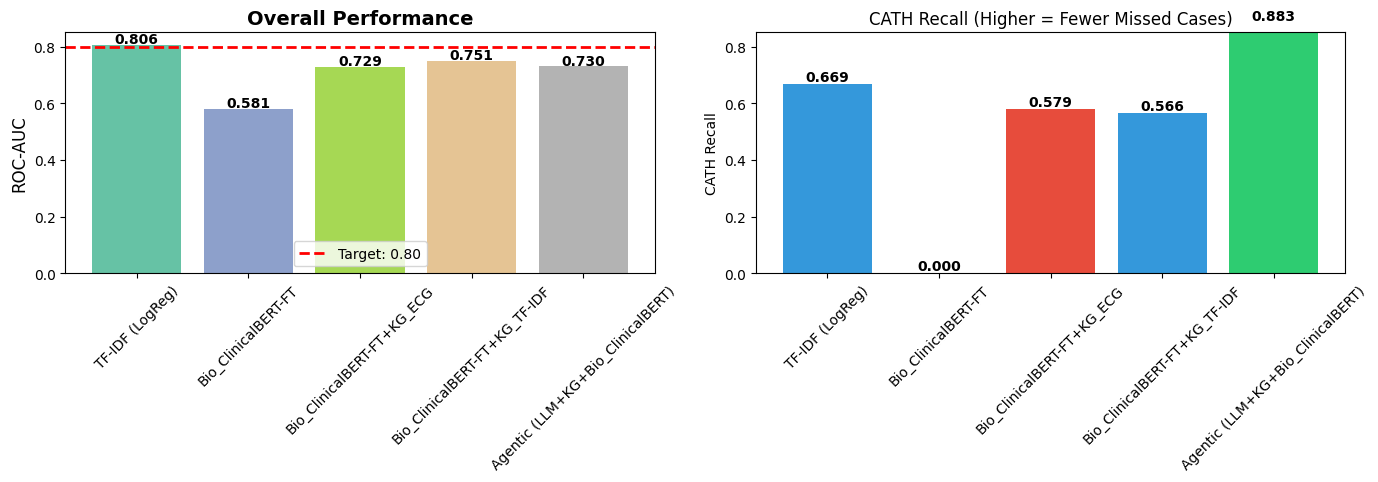


Comparison chart saved to results/model_comparison.png


In [65]:
## FINAL COMPARISON: all models Side-by-Side
print("FINAL MODEL COMPARISON")
print("="*80)

# Collect all results
comparison_data = []

# TF-IDF (Dummy Classifier)
if 'y_true_tfidf' in locals():
    comparison_data.append({
        'Model': 'TF-IDF (LogReg)',
        'ROC-AUC': roc_auc_score(y_true_tfidf, y_prob_tfidf),
        'Accuracy': (y_true_tfidf == y_pred_tfidf).mean(),
        'CATH Recall': recall_score(y_true_tfidf, y_pred_tfidf, pos_label=1),
        'CATH Precision': precision_score(y_true_tfidf, y_pred_tfidf, pos_label=1)
    })

# Baseline (No KG)
if 'y_true_bl' in locals():
    comparison_data.append({
        'Model': 'Bio_ClinicalBERT-FT',
        'ROC-AUC': roc_auc_score(y_true_bl, y_prob_bl),
        'Accuracy': (y_true_bl == y_pred_bl).mean(),
        'CATH Recall': recall_score(y_true_bl, y_pred_bl, pos_label=1),
        'CATH Precision': precision_score(y_true_bl, y_pred_bl, pos_label=1)
    })

# Simple KG
if 'y_true_simple' in locals():
    comparison_data.append({
        'Model': 'Bio_ClinicalBERT-FT+KG_ECG',
        'ROC-AUC': roc_auc_score(y_true_simple, y_prob_simple),
        'Accuracy': (y_true_simple == y_pred_simple).mean(),
        'CATH Recall': recall_score(y_true_simple, y_pred_simple, pos_label=1),
        'CATH Precision': precision_score(y_true_simple, y_pred_simple, pos_label=1)
    })

# Enhanced KG
if 'y_true_enh' in locals():
    comparison_data.append({
        'Model': 'Bio_ClinicalBERT-FT+KG_TF-IDF',
        'ROC-AUC': roc_auc_score(y_true_enh, y_prob_enh),
        'Accuracy': (y_true_enh == y_pred_enh).mean(),
        'CATH Recall': recall_score(y_true_enh, y_pred_enh, pos_label=1),
        'CATH Precision': precision_score(y_true_enh, y_pred_enh, pos_label=1)
    })

# Agentic System
if 'agentic_metrics' in locals():
    comparison_data.append({
        'Model': 'Agentic (LLM+KG+Bio_ClinicalBERT)',
        'ROC-AUC': agentic_metrics['overall_auc'],
        'Accuracy': agentic_metrics['overall_accuracy'],
        'CATH Recall': recall_score(agentic_metrics['y_true'], agentic_metrics['y_pred'], pos_label=1),
        'CATH Precision': precision_score(agentic_metrics['y_true'], agentic_metrics['y_pred'], pos_label=1)
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(3)

print("\n" + comparison_df.to_string(index=False))

# Save to CSV
comparison_df.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'), index=False)
print(f"\n Comparison saved to {RESULTS_DIR}/model_comparison.csv")

# === MI-STRATIFIED COMPARISON ===
if 'mi_label' in test_df.columns:
    print("\n" + "="*80)
    print("MI PATIENTS COMPARISON (CRITICAL!!)")
    print("="*80)

    mi_comparison = []

    # Get MI mask (same for all experiments since test set is fixed)
    mi_mask_test = test_df.loc[FIXED_TEST_INDICES, 'mi_label'].values == 1

    if 'y_true_tfidf' in locals() and len(y_true_tfidf) == len(mi_mask_test):
        y_true_mi = np.array(y_true_tfidf)[mi_mask_test]
        y_pred_mi = np.array(y_pred_tfidf)[mi_mask_test]
        y_prob_mi = np.array(y_prob_tfidf)[mi_mask_test]

        mi_comparison.append({
            'Model': 'TF-IDF',
            'MI Samples': mi_mask_test.sum(),
            'ROC-AUC': roc_auc_score(y_true_mi, y_prob_mi),
            'CATH Recall': recall_score(y_true_mi, y_pred_mi, pos_label=1),
            'Missed CATH': ((y_true_mi == 1) & (y_pred_mi == 0)).sum()
        })

    if 'y_true_bl' in locals() and len(y_true_bl) == len(mi_mask_test):
        y_true_mi = np.array(y_true_bl)[mi_mask_test]
        y_pred_mi = np.array(y_pred_bl)[mi_mask_test]
        y_prob_mi = np.array(y_prob_bl)[mi_mask_test]

        mi_comparison.append({
            'Model': 'Baseline',
            'MI Samples': mi_mask_test.sum(),
            'ROC-AUC': roc_auc_score(y_true_mi, y_prob_mi),
            'CATH Recall': recall_score(y_true_mi, y_pred_mi, pos_label=1),
            'Missed CATH': ((y_true_mi == 1) & (y_pred_mi == 0)).sum()
        })

    if 'y_true_simple' in locals() and len(y_true_simple) == len(mi_mask_test):
        y_true_mi = np.array(y_true_simple)[mi_mask_test]
        y_pred_mi = np.array(y_pred_simple)[mi_mask_test]
        y_prob_mi = np.array(y_prob_simple)[mi_mask_test]

        mi_comparison.append({
            'Model': 'Simple KG',
            'MI Samples': mi_mask_test.sum(),
            'ROC-AUC': roc_auc_score(y_true_mi, y_prob_mi),
            'CATH Recall': recall_score(y_true_mi, y_pred_mi, pos_label=1),
            'Missed CATH': ((y_true_mi == 1) & (y_pred_mi == 0)).sum()
        })

    if 'y_true_enh' in locals() and len(y_true_enh) == len(mi_mask_test):
        y_true_mi = np.array(y_true_enh)[mi_mask_test]
        y_pred_mi = np.array(y_pred_enh)[mi_mask_test]
        y_prob_mi = np.array(y_prob_enh)[mi_mask_test]

        mi_comparison.append({
            'Model': 'Enhanced KG',
            'MI Samples': mi_mask_test.sum(),
            'ROC-AUC': roc_auc_score(y_true_mi, y_prob_mi),
            'CATH Recall': recall_score(y_true_mi, y_pred_mi, pos_label=1),
            'Missed CATH': ((y_true_mi == 1) & (y_pred_mi == 0)).sum()
        })

    if mi_comparison:
        mi_comparison_df = pd.DataFrame(mi_comparison)
        mi_comparison_df = mi_comparison_df.round(3)

        print("\n" + mi_comparison_df.to_string(index=False))
        print("\nLower 'Missed CATH' is CRITICAL - these are patients who need urgent treatment!!")

        mi_comparison_df.to_csv(os.path.join(RESULTS_DIR, 'mi_comparison.csv'), index=False)

# === PLOT COMPARISON ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall ROC-AUC
n_models = len(comparison_df)
colors = plt.cm.Set2(np.linspace(0, 1, n_models))  # Dynamic colors
axes[0].bar(comparison_df['Model'], comparison_df['ROC-AUC'], color=colors)
axes[0].set_ylabel('ROC-AUC', fontsize=12)
axes[0].set_title('Overall Performance', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 0.85)
axes[0].axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='Target: 0.80')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['ROC-AUC']):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha='center', fontweight='bold', fontsize=10)

# Plot 2: CATH Recall (Critical Metric)
axes[1].bar(comparison_df['Model'], comparison_df['CATH Recall'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_ylabel('CATH Recall')
axes[1].set_title('CATH Recall (Higher = Fewer Missed Cases)')
axes[1].set_ylim(0, 0.85)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['CATH Recall']):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nComparison chart saved to {RESULTS_DIR}/model_comparison.png")